# Homework 04: Building CNNs for Image Classification

## Due: Midnight on February 15 (with 2-hour grace period) and worth 85 points

In this assignment, you will take your first steps into designing and training convolutional neural networks (CNNs) for image classification. Starting from a simple baseline, you will experiment with modifications that reflect the kinds of design choices practitioners face every day. Along the way, you’ll see how architecture, hyperparameters, normalization, pooling strategies, and learning rate schedules can each shape a model’s performance.

The problems are organized to build on each other:

1. **Hyperparameters:** Begin with a baseline CNN and try variations in learning rate, layer width, depth, and dropout.
2. **Batch Normalization:** Add normalization after convolutional layers to stabilize training and speed convergence.
3. **Global Average Pooling:** Replace the flatten-and-dense head with a modern pooling layer, reducing parameters and improving generalization.
4. **ReduceLROnPlateau:** Explore a widely used learning rate scheduler that adapts when validation progress slows.
5. **Very Deep CNN:** Finally, run a VGG-16–style model to observe how deeper networks behave compared to smaller ones.

By the end of this homework, you will have hands-on experience with both classical and modern CNN design strategies, a sense of how different components affect learning, and a toolkit of techniques that will serve you in future image processing projects.

There are 10 graded questions, worth 8 points each, with 5 points free if you complete all of the graded questions in the homework.


## 1. Setup and Data Loading


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os,time,random,kagglehub

import tensorflow as tf
from tensorflow.keras import layers, Input, models, callbacks, regularizers,initializers
from tensorflow.keras.callbacks import Callback,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical, load_img, img_to_array
from tensorflow.keras.optimizers import Adam,AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img, img_to_array
from tensorflow.keras.layers import Dense,Input,Dropout,Flatten,MaxPooling2D,Conv2D,SeparableConv2D,GlobalAveragePooling2D,GlobalMaxPooling2D,BatchNormalization

from sklearn.model_selection import train_test_split

# utility code

# -------------------------
# Reproducibility settings
# -------------------------

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages

### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far

In [3]:

def plot_learning_curves(hist, title, verbose=True):

    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(),
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Testing and training sets already defined, accessed here as global variables

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Training and testing sets already defined, accessed here as global variables

In [4]:
# Uses globals: train_ds, val_ds, test_ds

def train_and_test(model,
                   epochs        = 500,
                   lr_schedule   = 1e-3,
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   batch_size    = 64,                # kept for API compatibility; ignored if datasets are batched
                   use_early_stopping = True,
                   patience      = 10,
                   min_delta     = 0.0001,
                   callbacks     = [],
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")

    # Choose optimizer
    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule)
    else:
        opt = optimizer

    # Compile
    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,
        verbose=verbose
    )

    cbs = ([early_stop] if use_early_stopping else []) + callbacks

    start = time.time()

    # Fit on tf.data datasets (already batched)
    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=cbs,
        verbose=verbose
    )

    # Determine best validation accuracy
    if use_early_stopping and hasattr(early_stop, "best_epoch") and early_stop.best_epoch is not None:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = int(np.argmax(history.history['val_accuracy']))
        best_acc   = history.history['val_accuracy'][best_epoch]

    plot_learning_curves(history, title=title)

    # Evaluate on tf.data test set
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")

    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history


### Load the Intel Image Classification Dataset  



In [5]:
path      = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir  = os.path.join(path, "seg_test/seg_test")

Using Colab cache for faster access to the 'intel-image-classification' dataset.


In [6]:
import os
import numpy as np
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

def list_files_and_labels(directory, class_names=None, exts=(".jpg", ".jpeg", ".png")):
    """
    Returns:
      filepaths: np.array[str]
      labels:    np.array[int32]
      class_names_used: list[str] in deterministic order
    """
    if class_names is None:
        class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
    else:
        # keep only classes that exist in this directory, preserve given order
        class_names = [c for c in class_names if os.path.isdir(os.path.join(directory, c))]

    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    filepaths = []
    labels = []

    for cname in class_names:
        folder = os.path.join(directory, cname)
        for fname in sorted(os.listdir(folder)):  # deterministic within class
            if fname.lower().endswith(exts):
                filepaths.append(os.path.join(folder, fname))
                labels.append(class_to_idx[cname])

    return np.array(filepaths), np.array(labels, dtype=np.int32), class_names


def stratified_split_indices(y, val_frac=0.2, seed=42):
    """
    Deterministic stratified split over indices.
    Returns: train_idx, val_idx (np arrays)
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    n = len(y)

    train_idx_list = []
    val_idx_list = []

    classes = np.unique(y)
    for c in classes:
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)
        n_val = int(np.floor(len(idx) * val_frac))
        val_idx_list.append(idx[:n_val])
        train_idx_list.append(idx[n_val:])

    train_idx = np.concatenate(train_idx_list)
    val_idx = np.concatenate(val_idx_list)

    # Optional: shuffle each split deterministically so batches mix classes
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return train_idx, val_idx


def make_image_dataset(filepaths, labels, img_size=(150, 150), batch_size=32,
                       shuffle=False, seed=42, cache_to_disk="/tmp/train_cache"): # This was previously set to None, but using disk caching can help prevent RAM issues with large datasets
    """
    Builds a tf.data.Dataset that loads images lazily from disk.
    - filepaths: np array of strings
    - labels:    np array of int32
    """
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        # shuffle file *references* (cheap), not image tensors
        ds = ds.shuffle(buffer_size=len(filepaths), seed=seed, reshuffle_each_iteration=True)

    def _load_and_preprocess(path, label):
        # read bytes -> decode -> resize -> float32 in [0,1]
        img_bytes = tf.io.read_file(path)
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.image.resize(img, img_size, method="bilinear")
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = ds.map(_load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if cache_to_disk is not None:
        # Disk caching avoids RAM blowups; /tmp is fine in Colab
        ds = ds.cache(cache_to_disk)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


# -------------------------
# Example usage for Intel dataset
# -------------------------

IMG_SIZE    = (150, 150)
INPUT_SHAPE = IMG_SIZE + (3,)
BATCH_SIZE  = 32
VAL_FRAC    = 0.2
SEED        = random_seed  # use your existing seed

# 1) List train files/labels deterministically
train_files, train_labels, class_names = list_files_and_labels(train_dir)

num_classes = len(class_names)

# 2) Stratified deterministic split of *indices* (no images loaded)
train_idx, val_idx = stratified_split_indices(train_labels, val_frac=VAL_FRAC, seed=SEED)

# 3) Slice file lists
files_train = train_files[train_idx]
y_train     = train_labels[train_idx]
files_val   = train_files[val_idx]
y_val       = train_labels[val_idx]

# 4) Build datasets (lazy image loading)
train_ds = make_image_dataset(files_train, y_train, img_size=IMG_SIZE,
                              batch_size=BATCH_SIZE, shuffle=True, seed=SEED,
                              cache_to_disk=None)  # or "/tmp/train_cache"

val_ds   = make_image_dataset(files_val, y_val, img_size=IMG_SIZE,
                              batch_size=BATCH_SIZE, shuffle=False,
                              cache_to_disk=None)  # or "/tmp/val_cache"

# 5) Test set: keep same class mapping as train
test_files, test_labels, _ = list_files_and_labels(test_dir, class_names=class_names)
test_ds = make_image_dataset(test_files, test_labels, img_size=IMG_SIZE,
                             batch_size=BATCH_SIZE, shuffle=False,
                             cache_to_disk=None)




### Examine The Dataset

In [6]:

def show_counts_from_labels(name, labels, class_names):
    c = Counter(labels.tolist())
    counts = {class_names[k]: c.get(k, 0) for k in range(len(class_names))}
    print(f"{name} per-class counts:", counts)

print("class_names:", class_names)
print("train examples:", len(files_train), "val examples:", len(files_val), "test examples:", len(test_files))

show_counts_from_labels("train", y_train, class_names)
show_counts_from_labels("val",   y_val,   class_names)
show_counts_from_labels("test",  test_labels, class_names)


class_names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
train examples: 11230 val examples: 2804 test examples: 3000
train per-class counts: {'buildings': 1753, 'forest': 1817, 'glacier': 1924, 'mountain': 2010, 'sea': 1820, 'street': 1906}
val per-class counts: {'buildings': 438, 'forest': 454, 'glacier': 480, 'mountain': 502, 'sea': 454, 'street': 476}
test per-class counts: {'buildings': 437, 'forest': 474, 'glacier': 553, 'mountain': 525, 'sea': 510, 'street': 501}


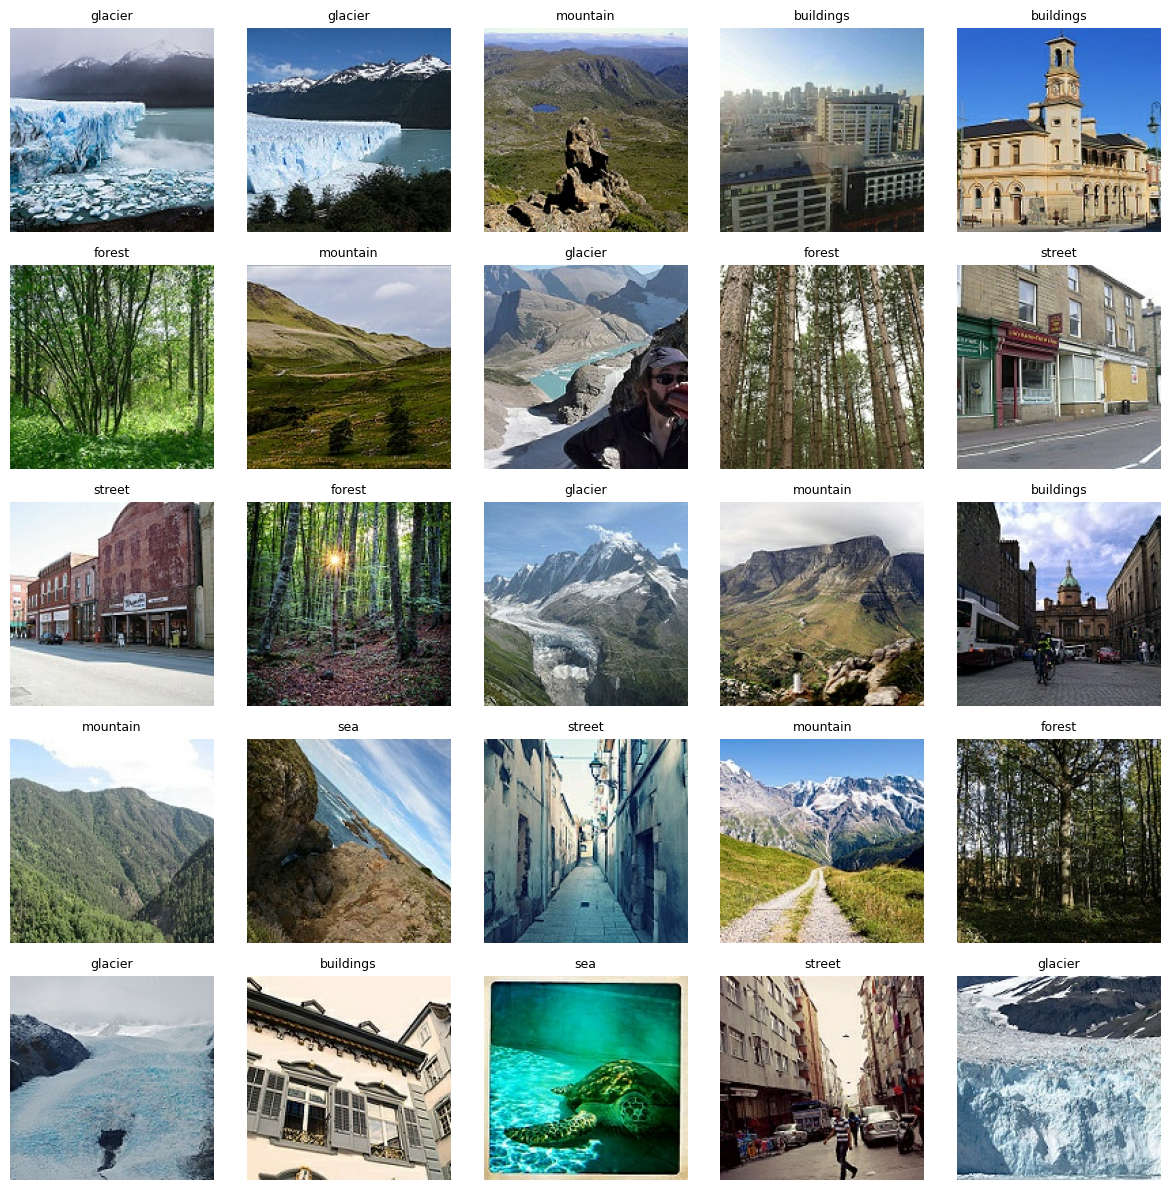

In [7]:
# Show 25 sample images

plt.figure(figsize=(12, 12))

# Take one batch from the dataset
images, labels = next(iter(train_ds))

for i in range(25):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(class_names[int(labels[i])], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Prelude: Baseline CNN (reference model)

This is our **reference** network: two Conv→Pool blocks with channels **32 → 64**, followed by a **single hidden head** `Dense(64)`. We use **He** initialization for ReLU activations and include an **optional `Dropout(0.5)`** to illustrate regularization—comment it out to gauge its impact (ha, not really optional!).

Use this model as a stable yardstick while you run **ablations**: change **one knob at a time** (e.g., widen/deepen the conv blocks, adjust dropout rate, add batch norm, tweak the LR schedule) and compare results back to this baseline. Focus on **training vs. validation curves**, the **generalization gap**, and how dropout affects **val loss/accuracy** and how long it takes for Early Stopping to kick in.


**Warning:** Sometimes I get this, I think because it has exploding gradients; if you run it again, it generally disappears....

![Screenshot 2025-09-20 at 12.34.00 PM.png](attachment:c750862e-b0c8-405f-ae87-323064e42737.png)


Baseline Model



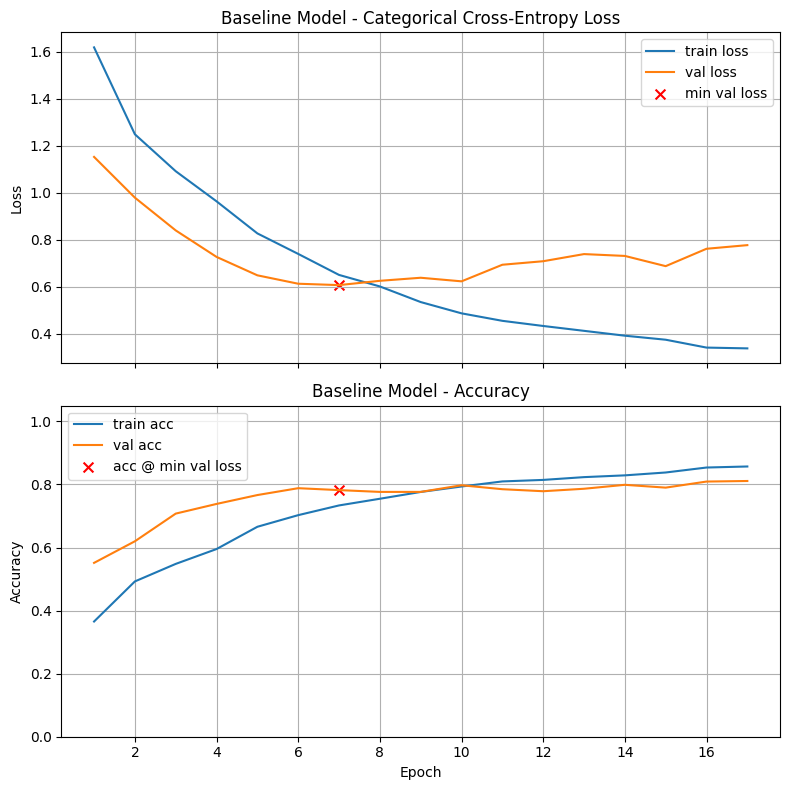

Final Training Loss:            0.3375
Final Training Accuracy:        0.8570
Final Validation Loss:          0.7770
Final Validation Accuracy:      0.8110
Minimum Validation Loss:        0.6068 (Epoch 7)
Validation Accuracy @ Min Loss: 0.7821

Test Loss: 0.6717
Test Accuracy: 0.7747

Validation-Test Gap (accuracy): 0.007430

Execution Time: 00:00:52


In [8]:
he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"Baseline Model")


## Problem One: Exploring Basic Hyperparameters

**Task:**
Copy the baseline CNN model into the next cell and experiment with basic hyperparameter changes. Your goal is to see whether small tweaks can improve validation accuracy (and hopefully speed up convergence or produce smoother training curves). You must **pick 3 of the following tweaks** and investigate their effect:

**Tweaks to Try:**

1. Adjust the learning rate (default for Adam is `1e-3`).
2. Change the width of the `Conv2D` layers (e.g., 64 → 128).
3. Add an extra `Conv2D` layer (e.g., stack 32 → 64 → 128).
4. Change the width of the `Dense(64 ...)` layer.
5. Add L2 regularization to the `Dense(64 ...)` layer (see the head of the network in Problem 5 for inspiration).  
6. Modify the dropout rate.
   
Observe the effect of each of your 3 choices in isolation and answer the graded questions.

**Optional:**
Combine two or more changes to see if they work together to improve results (example: try L2 regularization and reduced dropout in the head, as in Problem 5).


**Pro Tip:** Give each experiment a descriptive title, such as "Problem 1 -- Tweak 1 -- lr: 0.0005" to keep track of your experiments (see last cell in the notebook).


TWEAK 1: Adjusting Learning Rate (lower values)

Problem 1 -- Tweak 1 -- lr: 0.0005



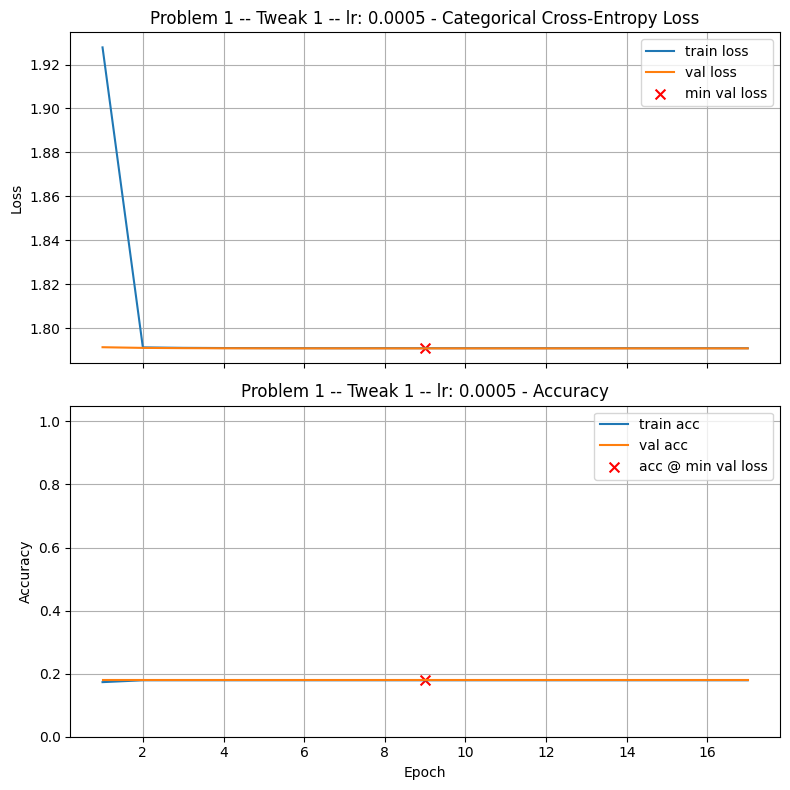

Final Training Loss:            1.7908
Final Training Accuracy:        0.1790
Final Validation Loss:          1.7908
Final Validation Accuracy:      0.1790
Minimum Validation Loss:        1.7908 (Epoch 9)
Validation Accuracy @ Min Loss: 0.1790

Test Loss: 1.7902
Test Accuracy: 0.1750

Validation-Test Gap (accuracy): 0.004030

Execution Time: 00:00:42

Problem 1 -- Tweak 1 -- lr: 0.0001



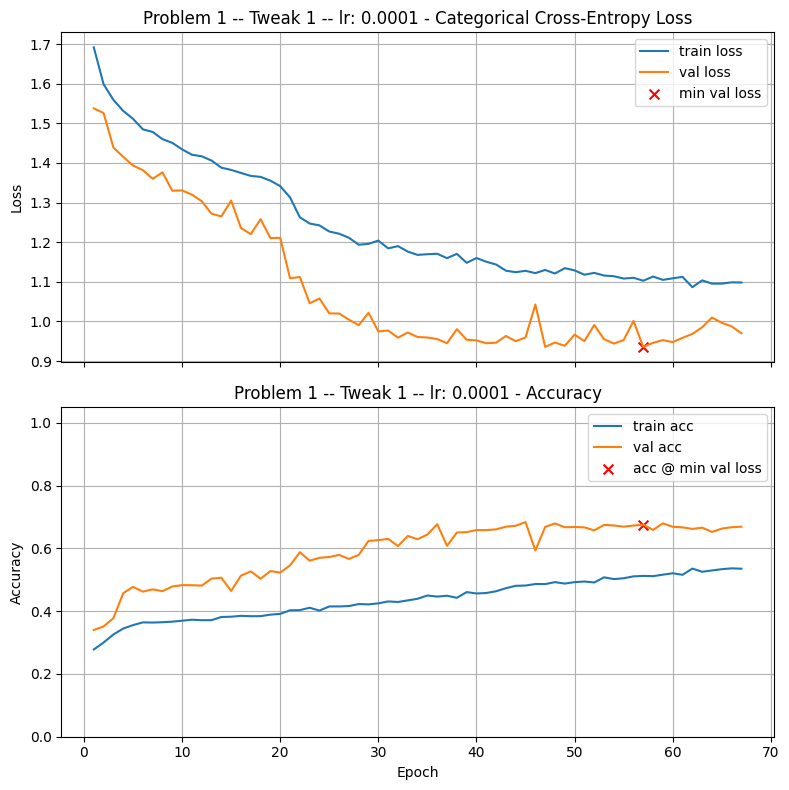

Final Training Loss:            1.0984
Final Training Accuracy:        0.5352
Final Validation Loss:          0.9704
Final Validation Accuracy:      0.6690
Minimum Validation Loss:        0.9357 (Epoch 57)
Validation Accuracy @ Min Loss: 0.6755

Test Loss: 0.9695
Test Accuracy: 0.6470

Validation-Test Gap (accuracy): 0.028464

Execution Time: 00:02:28


In [9]:
# Problem One: Exploring Basic Hyperparameters
# Testing 3 tweaks in isolation: Learning Rate, Conv2D Widths, and Dropout Rate

he = initializers.HeNormal()

# ---------- TWEAK 1: Adjust Learning Rate ----------
print("\n" + "="*70)
print("TWEAK 1: Adjusting Learning Rate (lower values)")
print("="*70)

# Test lower learning rates: 5e-4 and 1e-4
for lr in [5e-4, 1e-4]:
    model_tweak1 = models.Sequential([
        Input(shape=INPUT_SHAPE),
        Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
        MaxPooling2D(2),
        Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
        MaxPooling2D(2),
        Flatten(),
        Dense(64, activation="relu", kernel_initializer=he),
        Dropout(0.5),
        Dense(num_classes, activation="softmax")
    ])

    train_and_test(model_tweak1, lr_schedule=lr, title=f"Problem 1 -- Tweak 1 -- lr: {lr}")


TWEAK 2: Increasing Conv2D Layer Widths

Problem 1 -- Tweak 2 -- Conv widths: 64->128



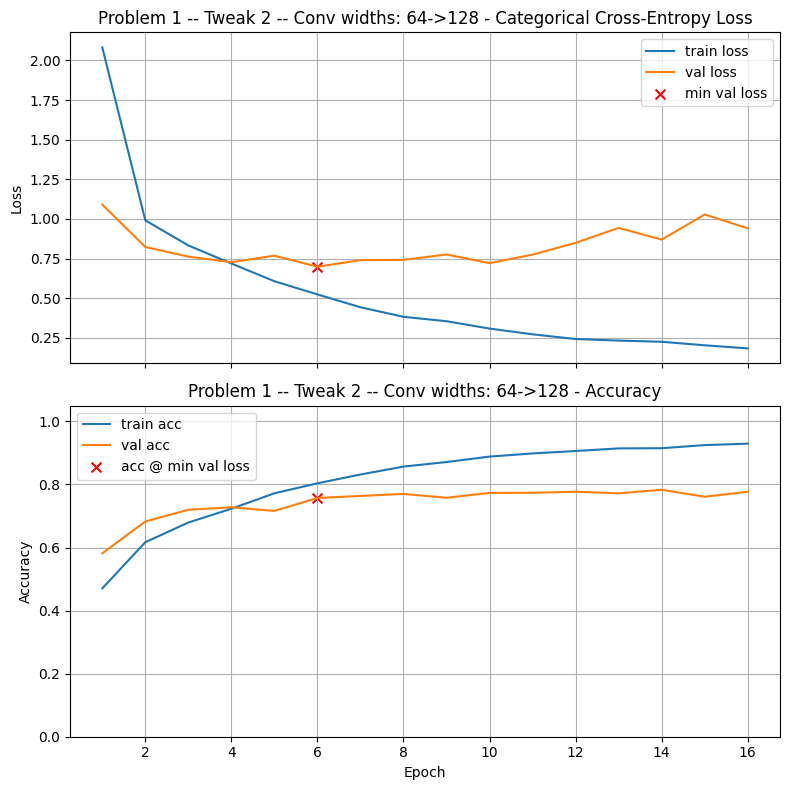

Final Training Loss:            0.1834
Final Training Accuracy:        0.9294
Final Validation Loss:          0.9408
Final Validation Accuracy:      0.7767
Minimum Validation Loss:        0.6985 (Epoch 6)
Validation Accuracy @ Min Loss: 0.7571

Test Loss: 0.7262
Test Accuracy: 0.7620

Validation-Test Gap (accuracy): 0.004867

Execution Time: 00:00:56


In [10]:
# ---------- TWEAK 2: Change Conv2D Layer Widths (Increase Channels) ----------
print("\n" + "="*70)
print("TWEAK 2: Increasing Conv2D Layer Widths")
print("="*70)

model_tweak2 = models.Sequential([
    Input(shape=INPUT_SHAPE),
    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),  # 32 -> 64
    MaxPooling2D(2),
    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),  # 64 -> 128
    MaxPooling2D(2),
    Flatten(),
    Dense(64, activation="relu", kernel_initializer=he),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_tweak2, title="Problem 1 -- Tweak 2 -- Conv widths: 64->128")


TWEAK 6: Reducing Dropout Rate

Problem 1 -- Tweak 6 -- Dropout: 0.3



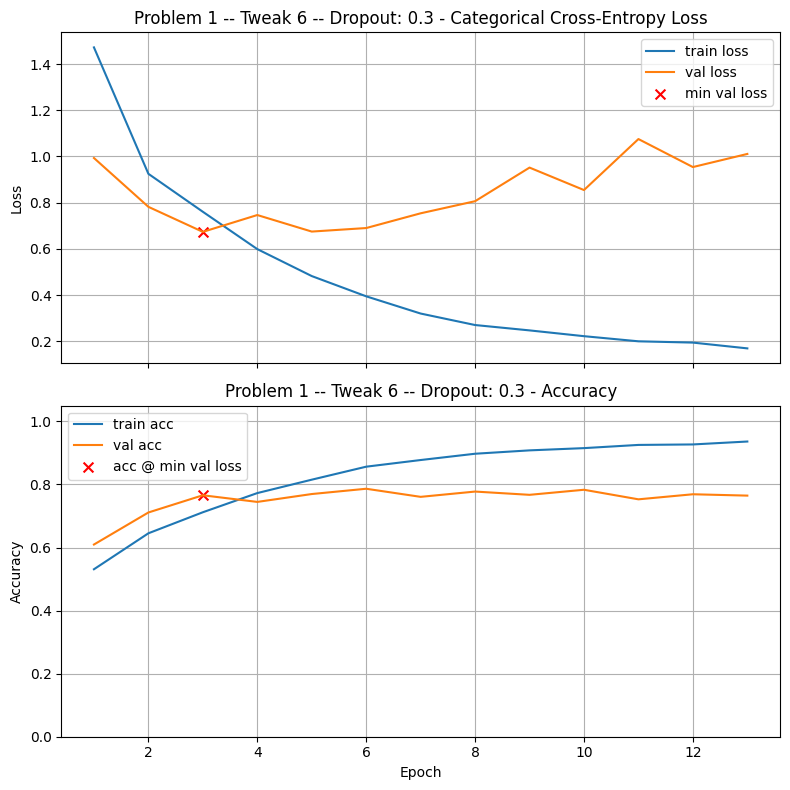

Final Training Loss:            0.1690
Final Training Accuracy:        0.9362
Final Validation Loss:          1.0111
Final Validation Accuracy:      0.7646
Minimum Validation Loss:        0.6736 (Epoch 3)
Validation Accuracy @ Min Loss: 0.7657

Test Loss: 0.7043
Test Accuracy: 0.7590

Validation-Test Gap (accuracy): 0.006692

Execution Time: 00:00:34

Problem 1 -- Tweak 6 -- Dropout: 0.2



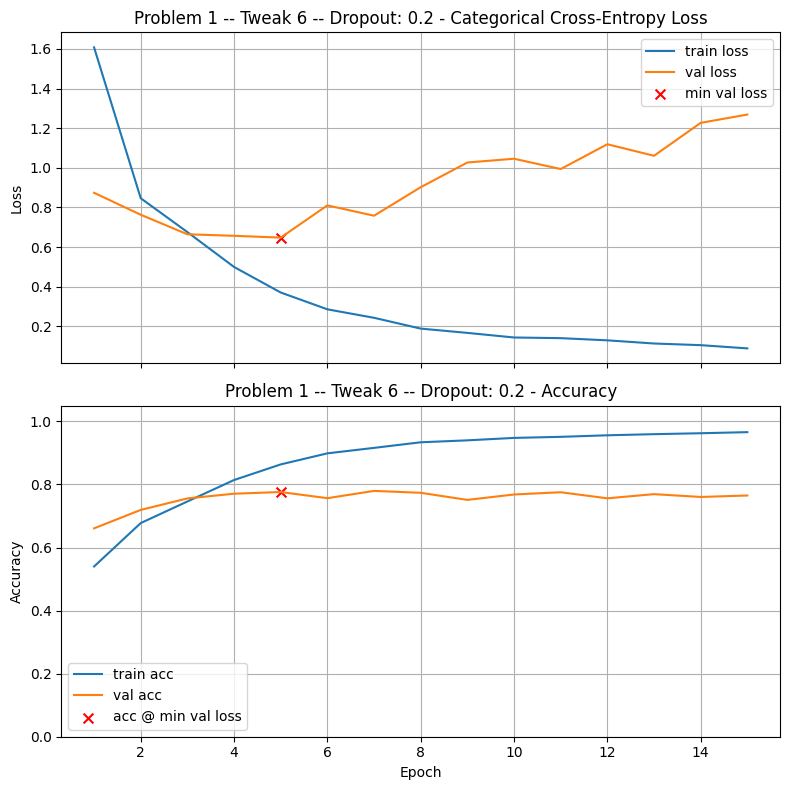

Final Training Loss:            0.0888
Final Training Accuracy:        0.9659
Final Validation Loss:          1.2689
Final Validation Accuracy:      0.7650
Minimum Validation Loss:        0.6479 (Epoch 5)
Validation Accuracy @ Min Loss: 0.7760

Test Loss: 0.7014
Test Accuracy: 0.7777

Validation-Test Gap (accuracy): 0.001632

Execution Time: 00:00:38

Problem 1 experiments completed. Check results with print_results()
Baseline Model                          	0.7821	7
Problem 1 -- Tweak 6 -- Dropout: 0.2    	0.7760	5
Problem 1 -- Tweak 6 -- Dropout: 0.3    	0.7657	3
Problem 1 -- Tweak 2 -- Conv widths: 64->128	0.7571	6
Problem 1 -- Tweak 1 -- lr: 0.0001      	0.6755	57
Problem 1 -- Tweak 1 -- lr: 0.0005      	0.1790	9


In [11]:
# ---------- TWEAK 6: Modify Dropout Rate (Reduce Regularization) ----------
print("\n" + "="*70)
print("TWEAK 6: Reducing Dropout Rate")
print("="*70)

# Test lower dropout rates: 0.3 and 0.2
for do_rate in [0.3, 0.2]:
    model_tweak6 = models.Sequential([
        Input(shape=INPUT_SHAPE),
        Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
        MaxPooling2D(2),
        Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
        MaxPooling2D(2),
        Flatten(),
        Dense(64, activation="relu", kernel_initializer=he),
        Dropout(do_rate),
        Dense(num_classes, activation="softmax")
    ])

    train_and_test(model_tweak6, title=f"Problem 1 -- Tweak 6 -- Dropout: {do_rate}")

print("\n" + "="*70)
print("Problem 1 experiments completed. Check results with print_results()")
print_results()
print("="*70)

### Graded Questions

In [37]:
# Set a1a to the number of the individual "tweak" which provided the best validation accuracy at the epoch of minimum validation loss

a1a = 0             # Replace with integer 1 - 6; replace with 0 if you found no tweak which improved the results

In [38]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a1a = {a1a}')


a1a = 6


In [1]:
# Set a1b to the validation accuracy found by the choice specified in Question a1a.

a1b = 	0.7821             # Replace 0.0 with your answer

In [2]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a1b = {a1b:.4f}')

a1b = 0.7821


## Problem Two: Adding Batch Normalization

**Task:**
Take your best model from Problem One and add a `BatchNormalization()` layer immediately after each `Conv2D` layer. Batch normalization helps stabilize training and can improve convergence.

**Next Steps:**

* Train the model with batch normalization included after each `Conv2D` layer.
* Try at least one of tweaks from Problem 1 to see if you can improve your results in this new design.
* Compare the results to your earlier experiments and answer the graded questions.

**Optional:**
Try more than one hyperparameter change alongside batch normalization and see how they interact.




BATCH NORM + TWEAK 6: Reduced Dropout Rate

Problem 2 -- Batch Norm + Tweak 6 -- Dropout: 0.2



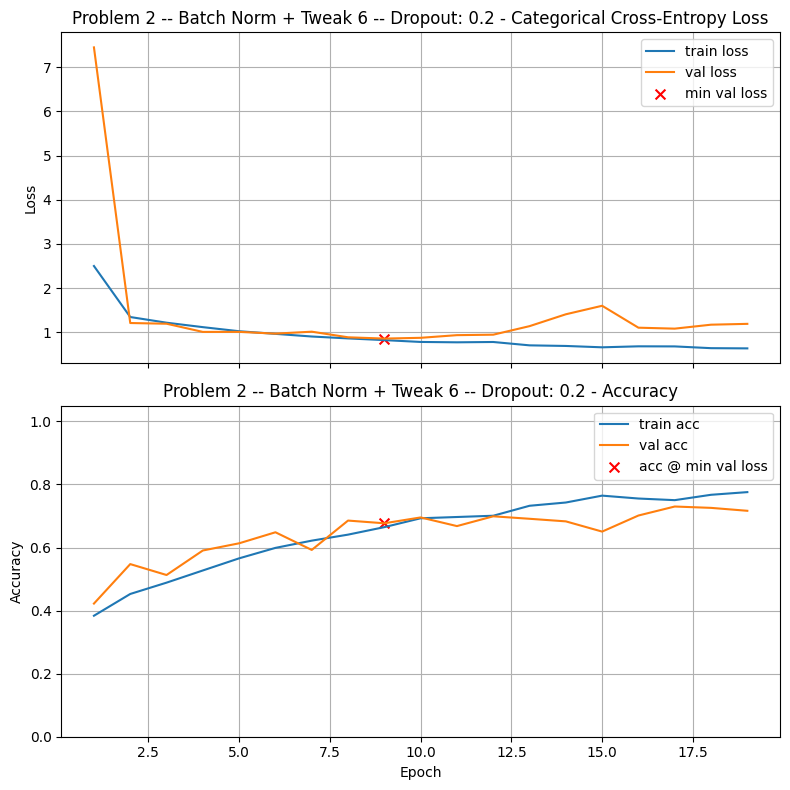

Final Training Loss:            0.6326
Final Training Accuracy:        0.7757
Final Validation Loss:          1.1883
Final Validation Accuracy:      0.7165
Minimum Validation Loss:        0.8546 (Epoch 9)
Validation Accuracy @ Min Loss: 0.6769

Test Loss: 0.8695
Test Accuracy: 0.6697

Validation-Test Gap (accuracy): 0.007223

Execution Time: 00:00:54


In [41]:
# Problem Two: Adding Batch Normalization
# Add BatchNormalization() after each Conv2D layer and combine with Problem 1 tweaks


# ---------- BATCH NORM + TWEAK 6 (Reduced Dropout) ----------
print("\n" + "="*70)
print("BATCH NORM + TWEAK 6: Reduced Dropout Rate")
print("="*70)

model_bn_tweak6 = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu", kernel_initializer=he),
    Dropout(0.2),  # From Problem 1
    Dense(num_classes, activation="softmax")
])

train_and_test(model_bn_tweak6, title="Problem 2 -- Batch Norm + Tweak 6 -- Dropout: 0.2")




BATCH NORM + TWEAK 6: Reduced Dropout Rate 0.3

Problem 2 -- Batch Norm + Tweak 6 -- Dropout: 0.3



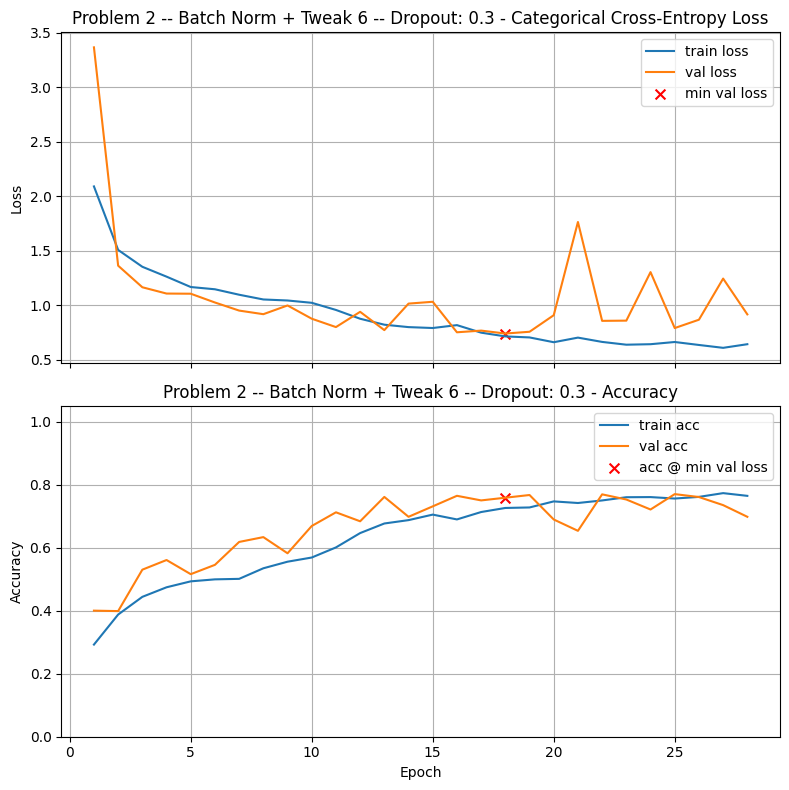

Final Training Loss:            0.6441
Final Training Accuracy:        0.7652
Final Validation Loss:          0.9177
Final Validation Accuracy:      0.6986
Minimum Validation Loss:        0.7420 (Epoch 18)
Validation Accuracy @ Min Loss: 0.7593

Test Loss: 0.7875
Test Accuracy: 0.7530

Validation-Test Gap (accuracy): 0.006272

Execution Time: 00:01:15


In [42]:

# ---------- BATCH NORM + TWEAK 6 (0.3 Reduced Dropout) ----------
print("\n" + "="*70)
print("BATCH NORM + TWEAK 6: Reduced Dropout Rate 0.3")
print("="*70)

model_bn_tweak6 = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu", kernel_initializer=he),
    Dropout(0.3),  # From Problem 1
    Dense(num_classes, activation="softmax")
])

train_and_test(model_bn_tweak6, title="Problem 2 -- Batch Norm + Tweak 6 -- Dropout: 0.3")




BATCH NORM + TWEAKS 2 & 6: Wider Conv + Reduced Dropout

Problem 2 -- Batch Norm + Tweak 2 64->128



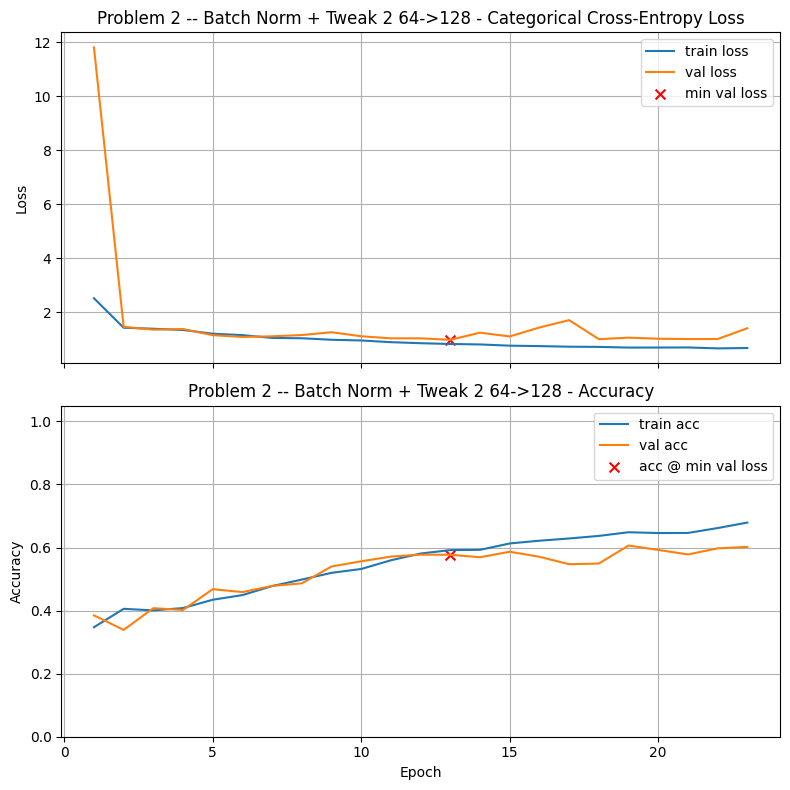

Final Training Loss:            0.6795
Final Training Accuracy:        0.6791
Final Validation Loss:          1.4127
Final Validation Accuracy:      0.6020
Minimum Validation Loss:        0.9827 (Epoch 13)
Validation Accuracy @ Min Loss: 0.5770

Test Loss: 1.0161
Test Accuracy: 0.5757

Validation-Test Gap (accuracy): 0.001366

Execution Time: 00:01:25

Problem 2 experiments completed. Check results with print_results()


In [45]:

# ---------- OPTIONAL: BATCH NORM + TWEAK 2 ----------
print("\n" + "="*70)
print("BATCH NORM + TWEAKS 2: Wider Conv ")
print("="*70)

model_bn_combined = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),  # Tweak 2
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),  # Tweak 2
    BatchNormalization(),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu", kernel_initializer=he),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_bn_combined, title="Problem 2 -- Batch Norm + Tweak 2 64->128")

print("\n" + "="*70)
print("Problem 2 experiments completed. Check results with print_results()")
print("="*70)


BATCH NORM + TWEAKS 2 & 6: Wider Conv + Reduced Dropout

Problem 2 -- Batch Norm + Tweaks 2 & 6



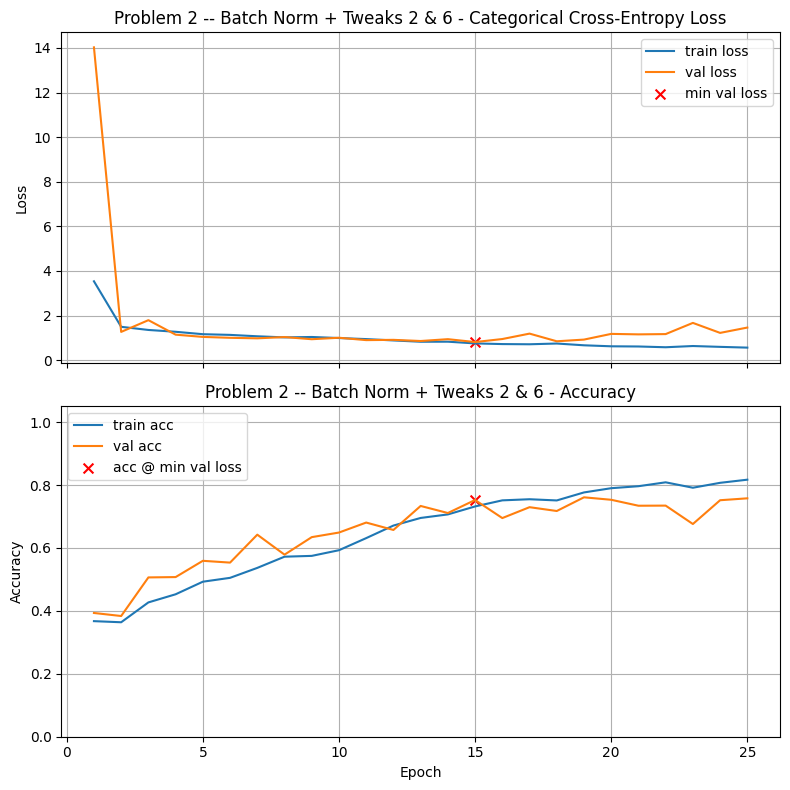

Final Training Loss:            0.5645
Final Training Accuracy:        0.8171
Final Validation Loss:          1.4638
Final Validation Accuracy:      0.7578
Minimum Validation Loss:        0.8141 (Epoch 15)
Validation Accuracy @ Min Loss: 0.7525

Test Loss: 0.9782
Test Accuracy: 0.7493

Validation-Test Gap (accuracy): 0.003163

Execution Time: 00:01:31

Problem 2 experiments completed. Check results with print_results()


In [43]:

# ---------- OPTIONAL: BATCH NORM + TWEAK 2 + TWEAK 6 (Combined) ----------
print("\n" + "="*70)
print("BATCH NORM + TWEAKS 2 & 6: Wider Conv + Reduced Dropout")
print("="*70)

model_bn_combined = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),  # Tweak 2
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),  # Tweak 2
    BatchNormalization(),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu", kernel_initializer=he),
    Dropout(0.2),  # Tweak 6
    Dense(num_classes, activation="softmax")
])

train_and_test(model_bn_combined, title="Problem 2 -- Batch Norm + Tweaks 2 & 6")

print("\n" + "="*70)
print("Problem 2 experiments completed. Check results with print_results()")
print("="*70)

In [46]:
print_results()

Problem 3 -- GAP + Tweaks 2 & 1         	0.8684	29
VGG-style Large                         	0.8648	11
Problem 3 -- BatchNorm + GAP -- Baseline	0.8623	36
Problem 3 -- GAP + Tweak 1 -- lr: 5e-4  	0.8570	36
Problem 3 -- GAP + Tweak 2 -- Conv: 64->128	0.8488	12
Baseline Model                          	0.7821	7
Problem 3 -- BatchNorm + GMP -- Baseline (GlobalMax)	0.7785	15
Problem 1 -- Tweak 6 -- Dropout: 0.2    	0.7760	5
Problem 1 -- Tweak 6 -- Dropout: 0.3    	0.7657	3
Problem 2 -- Batch Norm + Tweak 6 -- Dropout: 0.3	0.7593	18
Problem 2 -- Batch Norm + Tweak 1 -- lr: 5e-4	0.7582	35
Problem 1 -- Tweak 2 -- Conv widths: 64->128	0.7571	6
Problem 2 -- Batch Norm + Tweaks 2 & 6  	0.7525	15
Problem 2 -- Batch Norm + Tweak 6 -- Dropout: 0.2	0.6769	9
Problem 1 -- Tweak 1 -- lr: 0.0001      	0.6755	57
Problem 2 -- Batch Norm + Tweak 2 64->128	0.5770	13
Problem 2 -- Batch Norm + Tweak 2 -- Conv: 64->128	0.4943	28
Problem 1 -- Tweak 1 -- lr: 0.0005      	0.1790	9


### Graded Questions

In [19]:
# Set a2a to the number of the individual "tweak" which provided the best validation accuracy at the epoch of minimum validation loss

a2a = 0             # Replace with integer 1 - 6; replace with 0 if you found no tweak which improved the results

In [20]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a2a = {a2a}')


a2a = 0


In [21]:
# Set a2b to the validation accuracy found by the choice specified in Question a2a (your best model for this problem)

a2b = 0.7821           # Replace 0.0 with your answer

In [22]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a2b = {a2b:.4f}')

a2b = 0.7821


## Problem Three: Global Average Pooling

As we saw in this week's Coding Video,
**Global Average Pooling** is a simple layer that replaces the `Flatten → Dense` part of a CNN (please review that part of the Coding Notebook, which contains a description of this important technique).

In practice, swapping `Flatten` for `GlobalAveragePooling2D` often improves stability and validation performance — definitely worth considering!


**Task:**
Modify your best model from Problems 1 & 2 to use a `GlobalAveragePooling2D()` layer instead of a flatten-and-dense block.

**Next Steps:**

* Replace the sequence between the last `Conv2D` and output layers, for example:

     
          MaxPooling2D((2, 2)),
          Flatten(),
          Dense(64, activation='relu', kernel_initializer=initializers.HeNormal()),
          Dropout(0.5),   

  with a single `GlobalAveragePooling2D()` layer.
* Train the model and observe how performance and training curves change.
* Try at least one of tweaks from Problem 1 to see if you can improve your results in this new design.
* Compare results and answer the graded questions.

**Optional:**
Experiment with `GlobalMaxPooling2D()` as an alternative and compare its behavior to `GlobalAveragePooling2D()`.




GLOBAL AVERAGE POOLING: Baseline with BatchNorm + GAP

Problem 3 -- BatchNorm + GAP -- Baseline



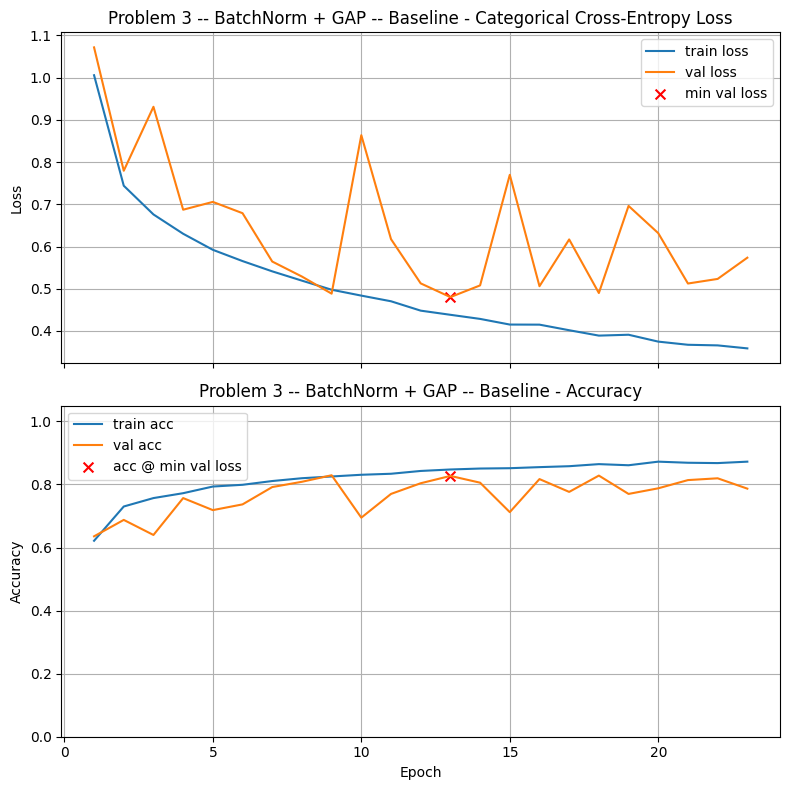

Final Training Loss:            0.3587
Final Training Accuracy:        0.8723
Final Validation Loss:          0.5735
Final Validation Accuracy:      0.7867
Minimum Validation Loss:        0.4802 (Epoch 13)
Validation Accuracy @ Min Loss: 0.8270

Test Loss: 0.4969
Test Accuracy: 0.8237

Validation-Test Gap (accuracy): 0.003366

Execution Time: 00:00:59


In [52]:
# Problem Three: Global Average Pooling
# Replace Flatten + Dense head with GlobalAveragePooling2D()
# Keep BatchNormalization from Problem 2 as it improved results


# ---------- BATCH NORM + GLOBAL AVERAGE POOLING (Baseline) ----------
print("\n" + "="*70)
print("GLOBAL AVERAGE POOLING: Baseline with BatchNorm + GAP")
print("="*70)

model_gap_baseline = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    # Replace Flatten() + Dense(64) + Dropout(0.5) with GlobalAveragePooling2D()
    GlobalAveragePooling2D(),

    Dense(num_classes, activation="softmax")
])

train_and_test(model_gap_baseline, title="Problem 3 -- BatchNorm + GAP -- Baseline")



GAP + TWEAK 2: Wider Conv Channels

Problem 3 -- GAP + Tweak 6 -- Dropout 0.2



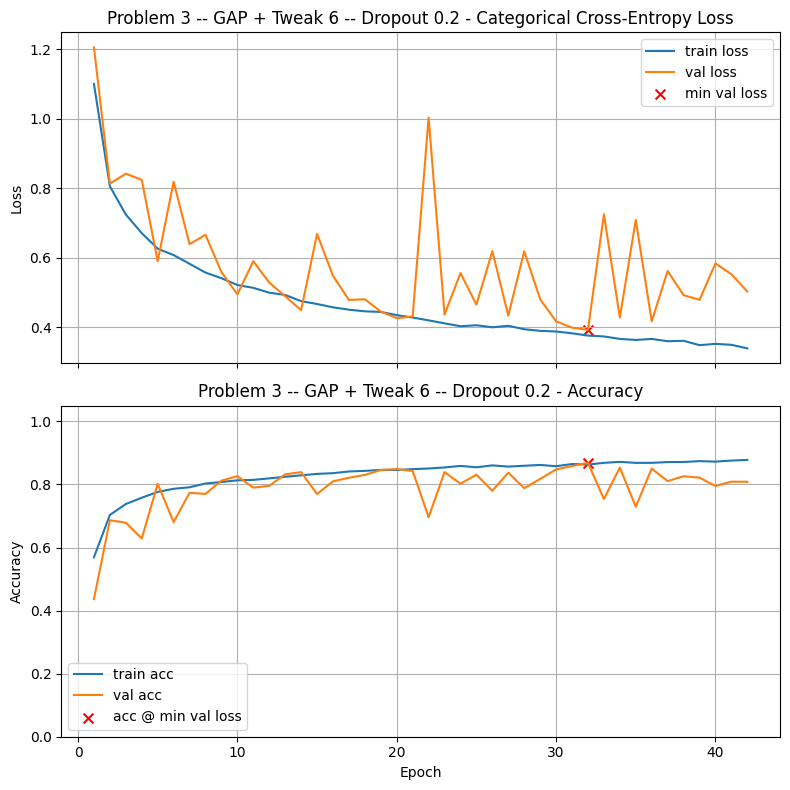

Final Training Loss:            0.3397
Final Training Accuracy:        0.8778
Final Validation Loss:          0.5032
Final Validation Accuracy:      0.8085
Minimum Validation Loss:        0.3930 (Epoch 32)
Validation Accuracy @ Min Loss: 0.8684

Test Loss: 0.4143
Test Accuracy: 0.8590

Validation-Test Gap (accuracy): 0.009402

Execution Time: 00:01:44


In [51]:

# ---------- GAP + TWEAK 6 (Dropout) ----------
print("\n" + "="*70)
print("GAP + TWEAK 2: Wider Conv Channels")
print("="*70)

model_gap_tweak2 = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),  # 32 -> 64
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),  # 64 -> 128
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dropout(0.2),  # Tweak 6
    Dense(num_classes, activation="softmax")
])

train_and_test(model_gap_tweak2, title="Problem 3 -- GAP + Tweak 6 -- Dropout 0.2")



GAP + TWEAK 2: Wider Conv Channels

Problem 3 -- GAP + Tweak 2 + 6 -- 64->128 + Dropout 0.2



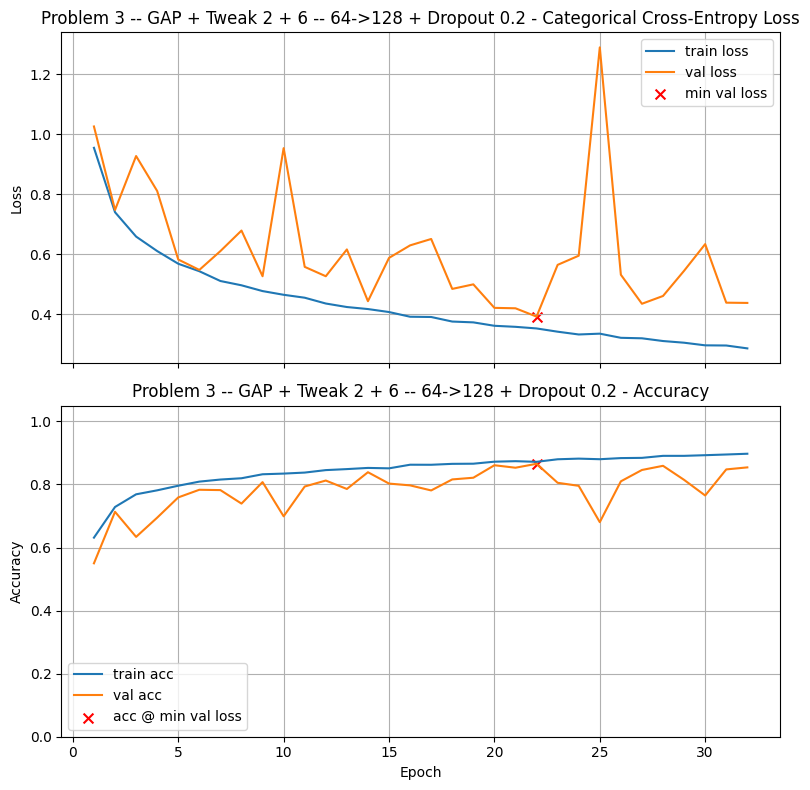

Final Training Loss:            0.2862
Final Training Accuracy:        0.8974
Final Validation Loss:          0.4377
Final Validation Accuracy:      0.8541
Minimum Validation Loss:        0.3921 (Epoch 22)
Validation Accuracy @ Min Loss: 0.8655

Test Loss: 0.4133
Test Accuracy: 0.8603

Validation-Test Gap (accuracy): 0.005216

Execution Time: 00:01:51


In [53]:

# ---------- GAP + TWEAK 2 + 6 (Wide Conv + Dropout) ----------
print("\n" + "="*70)
print("GAP + TWEAK 2: Wider Conv Channels")
print("="*70)

model_gap_tweak2 = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),  # 32 -> 64
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),  # 64 -> 128
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dropout(0.2),  # Tweak 6
    Dense(num_classes, activation="softmax")
])

train_and_test(model_gap_tweak2, title="Problem 3 -- GAP + Tweak 2 + 6 -- 64->128 + Dropout 0.2")




GAP + TWEAK 2: Wider Conv Channels

Problem 3 -- GAP + Tweak 2 -- Conv: 64->128



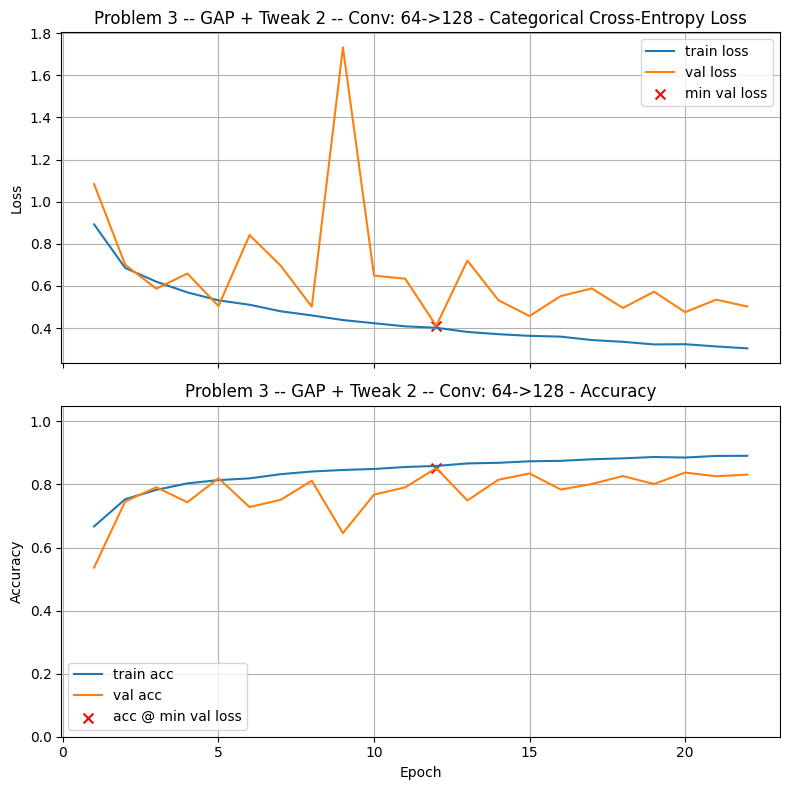

Final Training Loss:            0.3038
Final Training Accuracy:        0.8908
Final Validation Loss:          0.5024
Final Validation Accuracy:      0.8313
Minimum Validation Loss:        0.4108 (Epoch 12)
Validation Accuracy @ Min Loss: 0.8520

Test Loss: 0.4240
Test Accuracy: 0.8513

Validation-Test Gap (accuracy): 0.000664

Execution Time: 00:01:17


In [54]:
# ---------- GAP + TWEAK 2 (Wider Conv Channels) ----------
print("\n" + "="*70)
print("GAP + TWEAK 2: Wider Conv Channels")
print("="*70)

model_gap_tweak2 = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),  # 32 -> 64
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),  # 64 -> 128
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),

    Dense(num_classes, activation="softmax")
])

train_and_test(model_gap_tweak2, title="Problem 3 -- GAP + Tweak 2 -- Conv: 64->128")



GAP + TWEAK 1: Lower Learning Rate

Problem 3 -- GAP + Tweak 1 -- lr: 5e-4



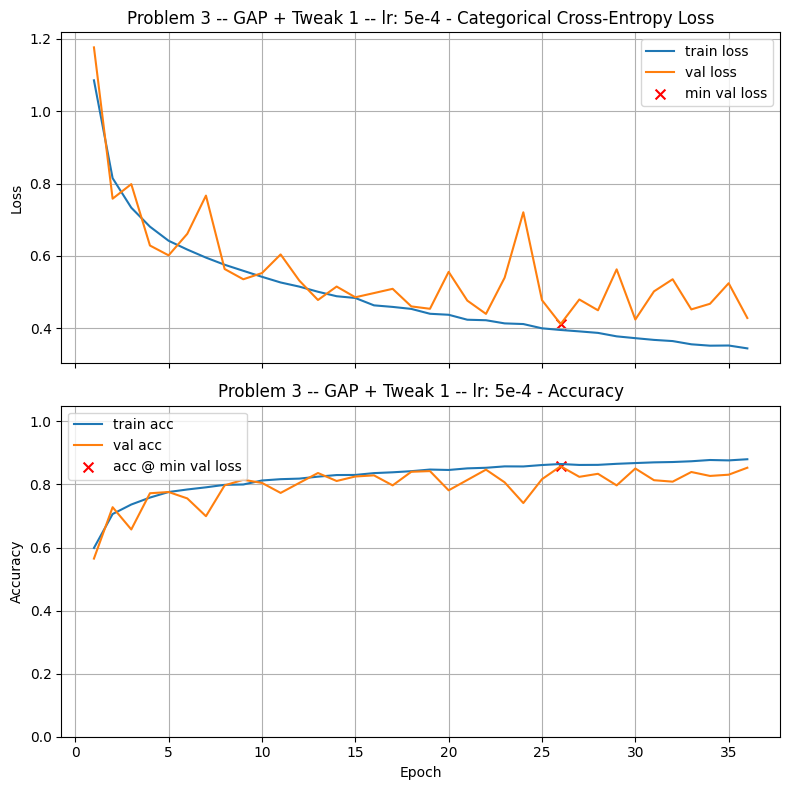

Final Training Loss:            0.3443
Final Training Accuracy:        0.8800
Final Validation Loss:          0.4283
Final Validation Accuracy:      0.8531
Minimum Validation Loss:        0.4116 (Epoch 26)
Validation Accuracy @ Min Loss: 0.8577

Test Loss: 0.4271
Test Accuracy: 0.8550

Validation-Test Gap (accuracy): 0.002703

Execution Time: 00:01:27


In [55]:


# ---------- GAP + TWEAK 1 (Lower Learning Rate) ----------
print("\n" + "="*70)
print("GAP + TWEAK 1: Lower Learning Rate")
print("="*70)

model_gap_tweak1 = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),

    Dense(num_classes, activation="softmax")
])

train_and_test(model_gap_tweak1, lr_schedule=5e-4, title="Problem 3 -- GAP + Tweak 1 -- lr: 5e-4")




GAP + TWEAKS 2 & 1: Wider Conv + Lower LR

Problem 3 -- GAP + Tweaks 2 & 1



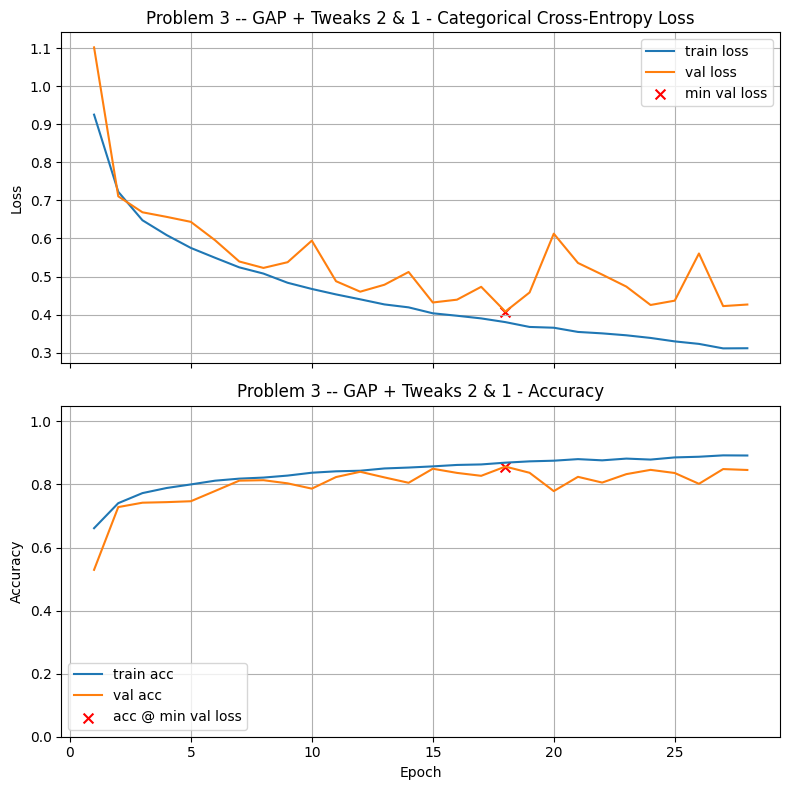

Final Training Loss:            0.3116
Final Training Accuracy:        0.8918
Final Validation Loss:          0.4265
Final Validation Accuracy:      0.8459
Minimum Validation Loss:        0.4079 (Epoch 18)
Validation Accuracy @ Min Loss: 0.8566

Test Loss: 0.4246
Test Accuracy: 0.8553

Validation-Test Gap (accuracy): 0.001300

Execution Time: 00:01:36


In [56]:

# ---------- GAP + TWEAK 2 + TWEAK 1 (Wider Conv + Lower LR) ----------
print("\n" + "="*70)
print("GAP + TWEAKS 2 & 1: Wider Conv + Lower LR")
print("="*70)

model_gap_combined = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),  # Tweak 2
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),  # Tweak 2
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),

    Dense(num_classes, activation="softmax")
])

train_and_test(model_gap_combined, lr_schedule=5e-4, title="Problem 3 -- GAP + Tweaks 2 & 1")




OPTIONAL: Global Max Pooling (Alternative)

Problem 3 -- BatchNorm + GMP -- Baseline (GlobalMax)



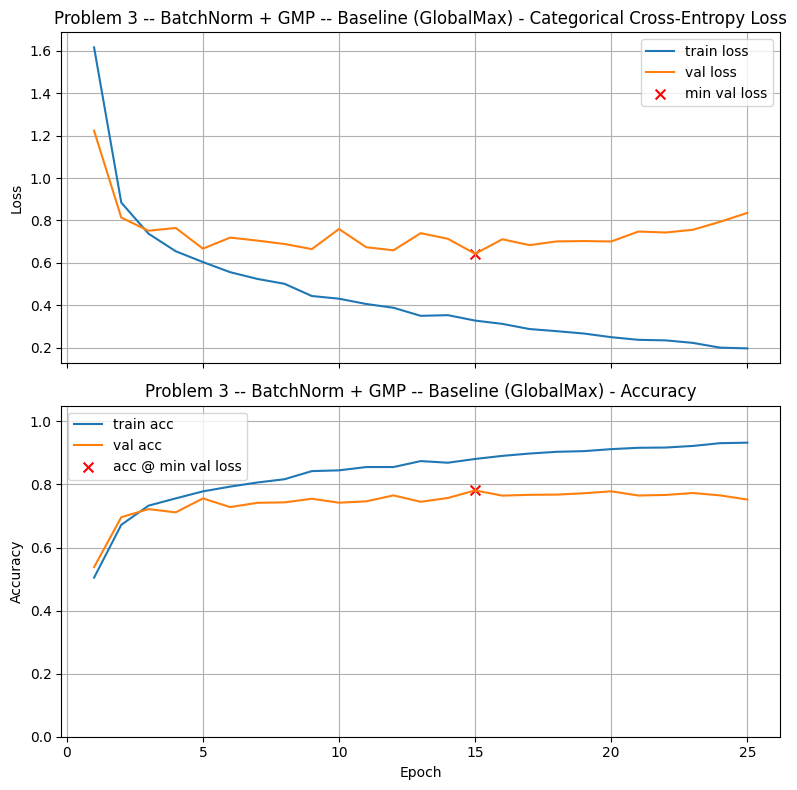

Final Training Loss:            0.1961
Final Training Accuracy:        0.9325
Final Validation Loss:          0.8356
Final Validation Accuracy:      0.7521
Minimum Validation Loss:        0.6427 (Epoch 15)
Validation Accuracy @ Min Loss: 0.7810

Test Loss: 0.6281
Test Accuracy: 0.7730

Validation-Test Gap (accuracy): 0.008027

Execution Time: 00:01:04

Problem 3 experiments completed. Check results with print_results()


In [57]:

# ---------- OPTIONAL: GLOBAL MAX POOLING (Alternative to GAP) ----------
print("\n" + "="*70)
print("OPTIONAL: Global Max Pooling (Alternative)")
print("="*70)

model_gmp_baseline = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    # Use GlobalMaxPooling2D instead of GlobalAveragePooling2D for comparison
    GlobalMaxPooling2D(),

    Dense(num_classes, activation="softmax")
])

train_and_test(model_gmp_baseline, title="Problem 3 -- BatchNorm + GMP -- Baseline (GlobalMax)")

print("\n" + "="*70)
print("Problem 3 experiments completed. Check results with print_results()")
print("="*70)

In [58]:
print_results()

Problem 3 -- GAP + Tweak 6 -- Dropout 0.2	0.8684	32
Problem 3 -- GAP + Tweak 2 + 6 -- 64->128 + Dropout 0.2	0.8655	22
VGG-style Large                         	0.8648	11
Problem 3 -- GAP + Tweak 1 -- lr: 5e-4  	0.8577	26
Problem 3 -- GAP + Tweaks 2 & 1         	0.8566	18
Problem 3 -- GAP + Tweak 2 -- Conv: 64->128	0.8520	12
Problem 3 -- BatchNorm + GAP -- Baseline	0.8270	13
Baseline Model                          	0.7821	7
Problem 3 -- BatchNorm + GMP -- Baseline (GlobalMax)	0.7810	15
Problem 1 -- Tweak 6 -- Dropout: 0.2    	0.7760	5
Problem 1 -- Tweak 6 -- Dropout: 0.3    	0.7657	3
Problem 2 -- Batch Norm + Tweak 6 -- Dropout: 0.3	0.7593	18
Problem 2 -- Batch Norm + Tweak 1 -- lr: 5e-4	0.7582	35
Problem 1 -- Tweak 2 -- Conv widths: 64->128	0.7571	6
Problem 2 -- Batch Norm + Tweaks 2 & 6  	0.7525	15
Problem 2 -- Batch Norm + Tweak 6 -- Dropout: 0.2	0.6769	9
Problem 1 -- Tweak 1 -- lr: 0.0001      	0.6755	57
Problem 2 -- Batch Norm + Tweak 2 64->128	0.5770	13
Problem 2 -- Batch Norm + Tw

### Graded Questions

In [15]:
# Set a3a to the number of the individual "tweak" which provided the best validation accuracy at the epoch of minimum validation loss

a3a = 6             # Replace with integer 1 - 6; replace with 0 if you found no tweak which improved the results

In [16]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a3a = {a3a}')


a3a = 6


In [17]:
# Set a3b to the validation accuracy found by the choice specified in Question a3a (your best model for this problem)

a3b = 0.8684            # Replace 0.0 with your answer

In [18]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a3b = {a3b:.4f}')

a3b = 0.8684


## Problem Four: ReduceLROnPlateau

`ReduceLROnPlateau` is a widely used learning rate scheduling technique. It monitors a validation metric (usually `val_loss`) and reduces the learning rate when progress stalls, allowing the model to refine training at a smaller step size. This is one of the most useful scheduling tools (along with the essential Early Stopping) to have in your toolbox.

**Task:**
Augment your best model found so far in Problems 1 - 3 with the `ReduceLROnPlateau` callback during training.

**Next Steps:**

* Add the callback parameter to `train_and_test`:

  ```python
  callbacks=[reduce_lr]
  ```

* Start with **`factor=0.5`** (monitor `val_loss`, `patience=2–3`, `cooldown=1`, `min_lr=1e-5` for Adam).
* **Practical playbook:**

  * If plateau persists after one reduction → try **`factor=0.3`**, then **`0.2`**.
  * If a reduction hurts validation noticeably → try **`factor=0.7–0.8`** or increase **`patience`**.
  * Leave **`cooldown=1`** unless you see too-frequent drops.
* Experiment with **`patience` = 3, 5, 8** and **`min_delta` = `1e-4` vs `1e-3`** to gauge sensitivity.
* Choose the configuration with the best validation results—or note that ReduceLROnPlateau didn’t help (rare!).
* Answer the graded questions.



In [59]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=3,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=1,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-5,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

# Your code here, add more cells as needed


Problem 4 -- ReduceLROnPlateau (factor=0.5, dropout=0.2)



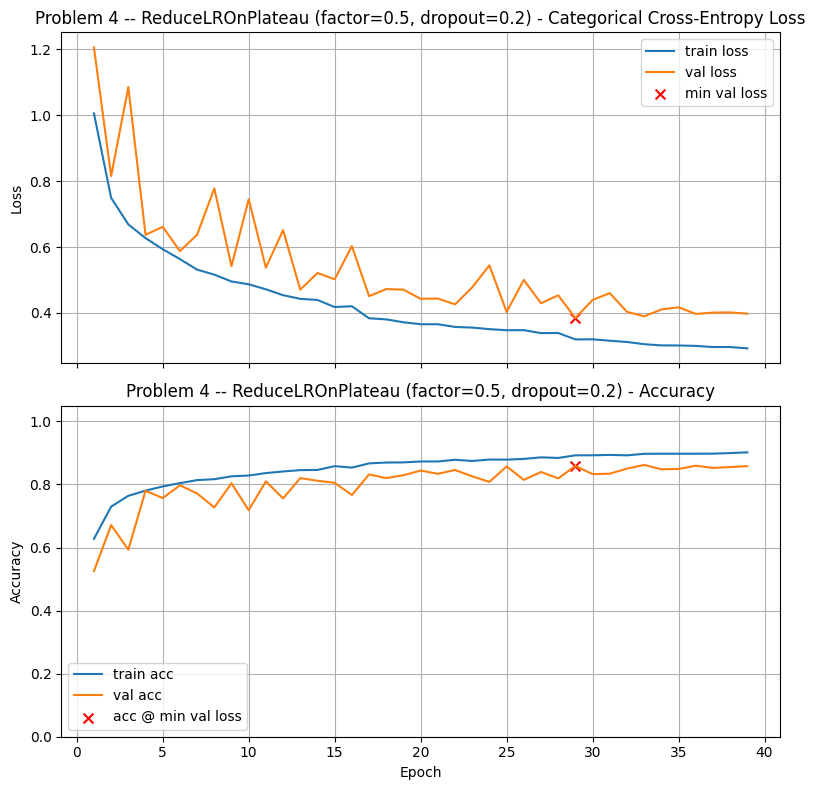

Final Training Loss:            0.2924
Final Training Accuracy:        0.9019
Final Validation Loss:          0.3978
Final Validation Accuracy:      0.8581
Minimum Validation Loss:        0.3845 (Epoch 29)
Validation Accuracy @ Min Loss: 0.8588

Test Loss: 0.4109
Test Accuracy: 0.8537

Validation-Test Gap (accuracy): 0.005107

Execution Time: 00:01:37


In [60]:
# Build the best model from Problems 1-3 and add dropout=0.2, then train with ReduceLROnPlateau

# Start with Problem 3's best model architecture and add dropout
model_reduce_lr_factor_05 = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), kernel_initializer=he, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), kernel_initializer=he, padding='same', activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation='softmax')
])

train_and_test(model_reduce_lr_factor_05,
               lr_schedule=1e-3,
               title="Problem 4 -- ReduceLROnPlateau (factor=0.5, dropout=0.2)",
               callbacks=[reduce_lr])



Problem 4 -- ReduceLROnPlateau (factor=0.3, dropout=0.2)



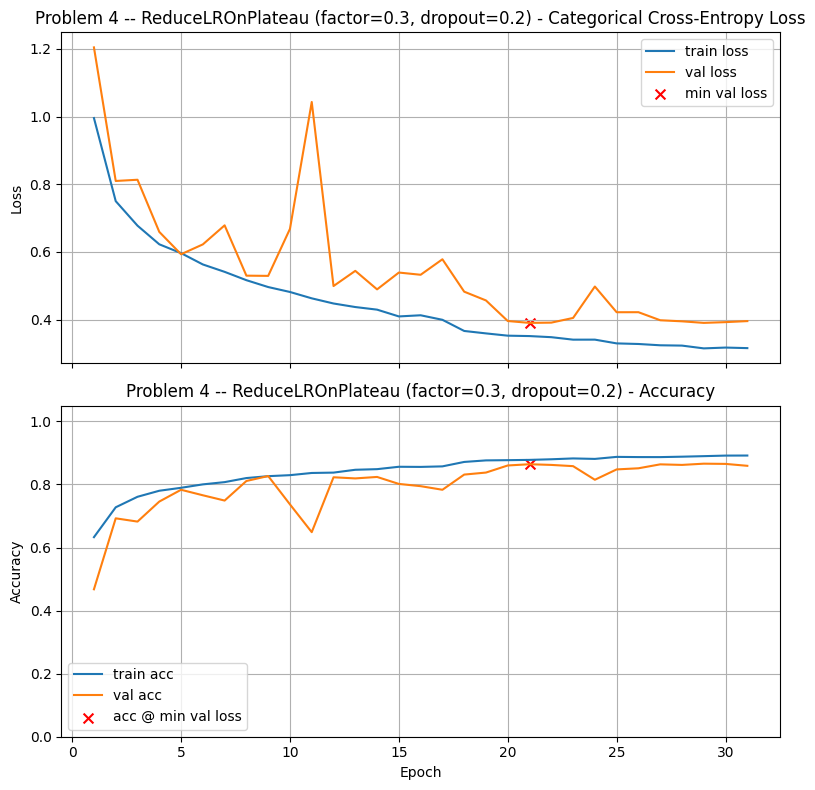

Final Training Loss:            0.3160
Final Training Accuracy:        0.8917
Final Validation Loss:          0.3958
Final Validation Accuracy:      0.8591
Minimum Validation Loss:        0.3905 (Epoch 21)
Validation Accuracy @ Min Loss: 0.8641

Test Loss: 0.4067
Test Accuracy: 0.8627

Validation-Test Gap (accuracy): 0.001456

Execution Time: 00:01:19


In [61]:
# Try factor=0.3 for comparison

reduce_lr_factor_03 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,            # More aggressive reduction
    patience=3,
    min_delta=1e-4,
    cooldown=1,
    min_lr=1e-5,
    verbose=0,
)

model_reduce_lr_factor_03 = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), kernel_initializer=he, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), kernel_initializer=he, padding='same', activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation='softmax')
])

train_and_test(model_reduce_lr_factor_03,
               lr_schedule=1e-3,
               title="Problem 4 -- ReduceLROnPlateau (factor=0.3, dropout=0.2)",
               callbacks=[reduce_lr_factor_03])



Problem 4 -- ReduceLROnPlateau (factor=0.2, dropout=0.2)



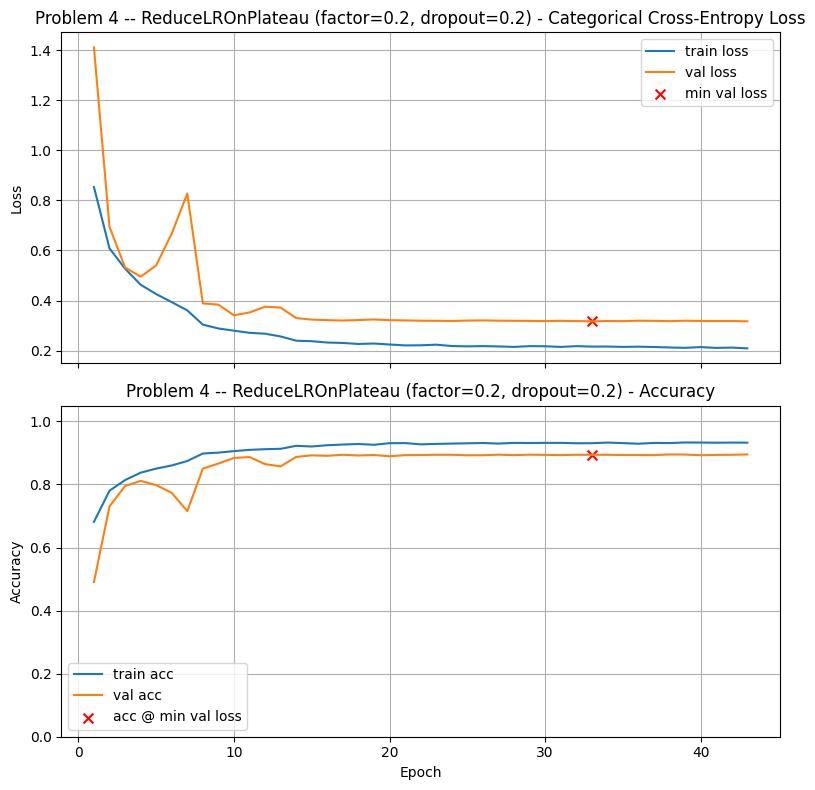

Final Training Loss:            0.2088
Final Training Accuracy:        0.9325
Final Validation Loss:          0.3169
Final Validation Accuracy:      0.8951
Minimum Validation Loss:        0.3168 (Epoch 33)
Validation Accuracy @ Min Loss: 0.8941

Test Loss: 0.3206
Test Accuracy: 0.8887

Validation-Test Gap (accuracy): 0.005413

Execution Time: 00:02:01


In [62]:
# Try factor=0.2 (even more aggressive)

reduce_lr_factor_02 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,            # Very aggressive reduction
    patience=3,
    min_delta=1e-4,
    cooldown=1,
    min_lr=1e-5,
    verbose=0,
)

model_reduce_lr_factor_02 = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), kernel_initializer=he, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), kernel_initializer=he, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), kernel_initializer=he, padding='same', activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation='softmax')
])

train_and_test(model_reduce_lr_factor_02,
               lr_schedule=1e-3,
               title="Problem 4 -- ReduceLROnPlateau (factor=0.2, dropout=0.2)",
               callbacks=[reduce_lr_factor_02])



Problem 4 -- ReduceLROnPlateau (factor=0.5, patience=5, dropout=0.2)



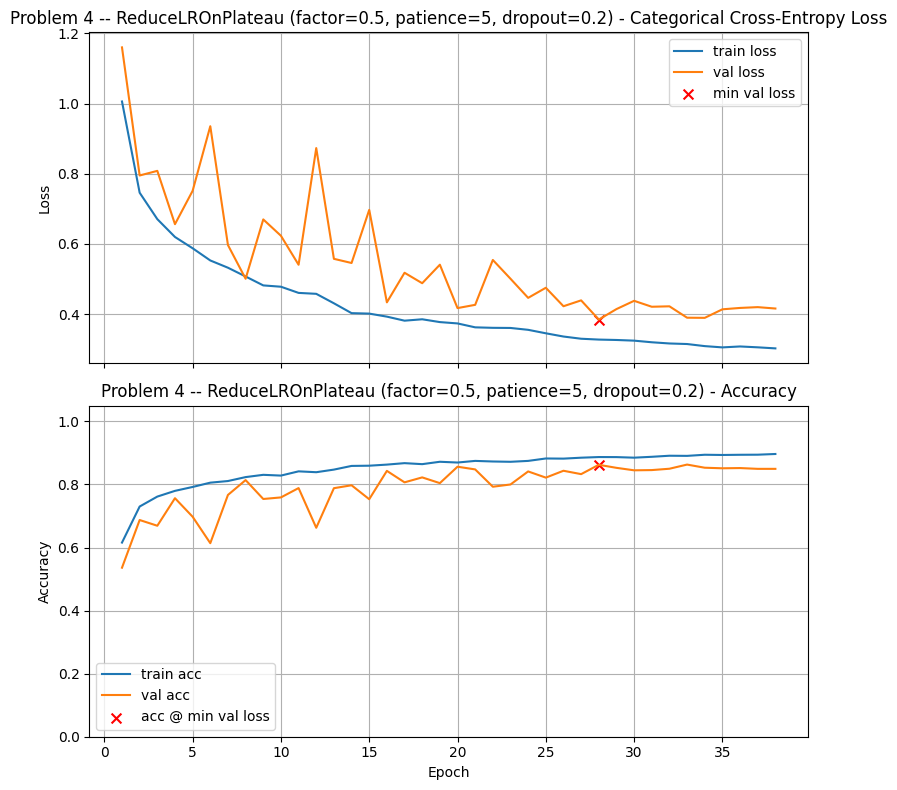

Final Training Loss:            0.3021
Final Training Accuracy:        0.8966
Final Validation Loss:          0.4158
Final Validation Accuracy:      0.8495
Minimum Validation Loss:        0.3843 (Epoch 28)
Validation Accuracy @ Min Loss: 0.8623

Test Loss: 0.4016
Test Accuracy: 0.8613

Validation-Test Gap (accuracy): 0.001006

Execution Time: 00:01:35

Problem 4 Results Summary (sorted by validation accuracy)
Problem 4 -- ReduceLROnPlateau (factor=0.2, dropout=0.2)	0.8941	33
Problem 3 -- GAP + Tweak 6 -- Dropout 0.2	0.8684	32
Problem 3 -- GAP + Tweak 2 + 6 -- 64->128 + Dropout 0.2	0.8655	22
VGG-style Large                         	0.8648	11
Problem 4 -- ReduceLROnPlateau (factor=0.3, dropout=0.2)	0.8641	21
Problem 4 -- ReduceLROnPlateau (factor=0.5, patience=5, dropout=0.2)	0.8623	28
Problem 4 -- ReduceLROnPlateau (factor=0.5, dropout=0.2)	0.8588	29
Problem 3 -- GAP + Tweak 1 -- lr: 5e-4  	0.8577	26
Problem 3 -- GAP + Tweaks 2 & 1         	0.8566	18
Problem 3 -- GAP + Tweak 2 -- Conv: 

In [63]:
# Optional: Try higher patience values (3, 5, 8) to see sensitivity

reduce_lr_patience_5 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,            # Higher patience
    min_delta=1e-4,
    cooldown=1,
    min_lr=1e-5,
    verbose=0,
)

model_patience_5 = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), kernel_initializer=he, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), kernel_initializer=he, padding='same', activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation='softmax')
])

train_and_test(model_patience_5,
               lr_schedule=1e-3,
               title="Problem 4 -- ReduceLROnPlateau (factor=0.5, patience=5, dropout=0.2)",
               callbacks=[reduce_lr_patience_5])

# Print all results sorted by validation accuracy
print("\n" + "="*80)
print("Problem 4 Results Summary (sorted by validation accuracy)")
print("="*80)
print_results()



Problem 4 -- ReduceLROnPlateau (factor=0.5, min_delta=1e-3, dropout=0.2)



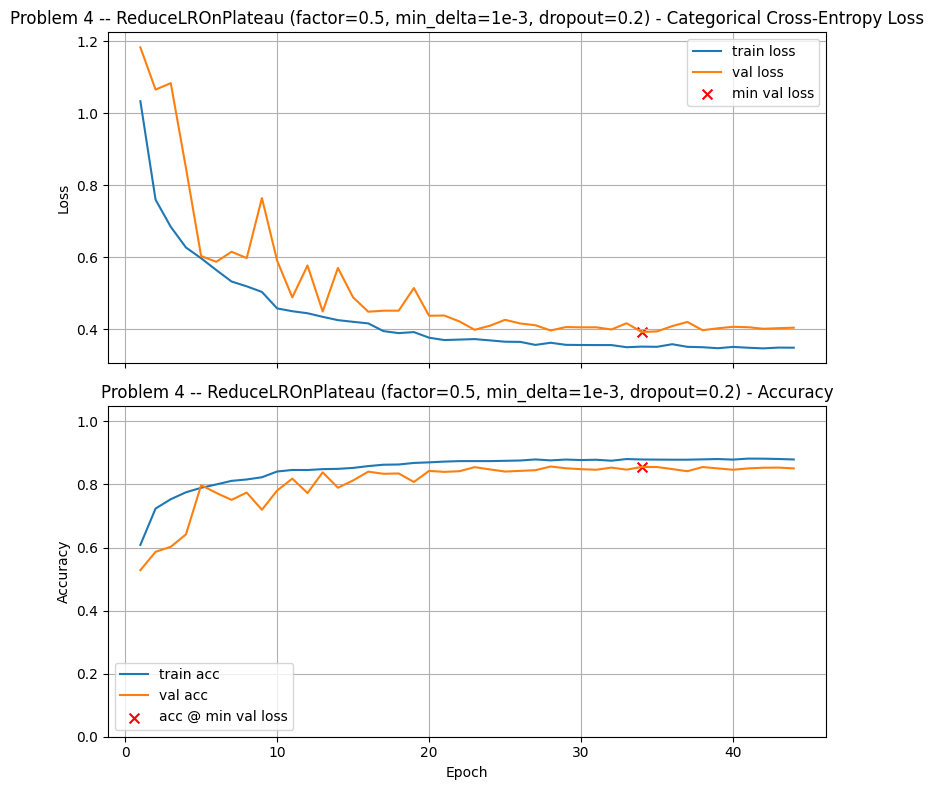

Final Training Loss:            0.3493
Final Training Accuracy:        0.8793
Final Validation Loss:          0.4048
Final Validation Accuracy:      0.8509
Minimum Validation Loss:        0.3929 (Epoch 34)
Validation Accuracy @ Min Loss: 0.8556

Test Loss: 0.4057
Test Accuracy: 0.8600

Validation-Test Gap (accuracy): 0.004437

Execution Time: 00:01:50


In [64]:
# Optional: Try min_delta variations to gauge sensitivity

reduce_lr_min_delta_003 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_delta=1e-3,        # More significant change required
    cooldown=1,
    min_lr=1e-5,
    verbose=0,
)

model_min_delta = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), kernel_initializer=he, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), kernel_initializer=he, padding='same', activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation='softmax')
])

train_and_test(model_min_delta,
               lr_schedule=1e-3,
               title="Problem 4 -- ReduceLROnPlateau (factor=0.5, min_delta=1e-3, dropout=0.2)",
               callbacks=[reduce_lr_min_delta_003])


In [65]:
print_results()

Problem 4 -- ReduceLROnPlateau (factor=0.2, dropout=0.2)	0.8941	33
Problem 3 -- GAP + Tweak 6 -- Dropout 0.2	0.8684	32
Problem 3 -- GAP + Tweak 2 + 6 -- 64->128 + Dropout 0.2	0.8655	22
VGG-style Large                         	0.8648	11
Problem 4 -- ReduceLROnPlateau (factor=0.3, dropout=0.2)	0.8641	21
Problem 4 -- ReduceLROnPlateau (factor=0.5, patience=5, dropout=0.2)	0.8623	28
Problem 4 -- ReduceLROnPlateau (factor=0.5, dropout=0.2)	0.8588	29
Problem 3 -- GAP + Tweak 1 -- lr: 5e-4  	0.8577	26
Problem 3 -- GAP + Tweaks 2 & 1         	0.8566	18
Problem 4 -- ReduceLROnPlateau (factor=0.5, min_delta=1e-3, dropout=0.2)	0.8556	34
Problem 3 -- GAP + Tweak 2 -- Conv: 64->128	0.8520	12
Problem 3 -- BatchNorm + GAP -- Baseline	0.8270	13
Baseline Model                          	0.7821	7
Problem 3 -- BatchNorm + GMP -- Baseline (GlobalMax)	0.7810	15
Problem 1 -- Tweak 6 -- Dropout: 0.2    	0.7760	5
Problem 1 -- Tweak 6 -- Dropout: 0.3    	0.7657	3
Problem 2 -- Batch Norm + Tweak 6 -- Dropout: 0.

### Graded Questions

In [3]:
# Set a4a to the factor parameter which gave the best validation accuracy at the point of minimum validation loss

a4a = 0.2             # Replace with your best factor value, or leave at 0.0 if reduce on plateau did not help at all

In [4]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a4a = {a4a:.2f}')

a4a = 0.20


In [13]:
# Set a4b to the validation accuracy found by the choice specified in Question a4a (your best model for this problem)

a4b = 0.8941             # Replace 0.0 with your answer

In [14]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a4b = {a4b:.4f}')

a4b = 0.8941


## Problem Five: A Very Deep CNN (VGG-16 Style)

 We will now experiment with the VGG-16 design introduced in the Coding Notebook and Video and see how it does on this dataset. For a beautiful description of the model and its significance, see [Explanation of VGG-16](https://viso.ai/deep-learning/vgg-very-deep-convolutional-networks/) :
        

![Screenshot 2025-09-19 at 6.50.24 AM.png](attachment:62fa0824-bb06-4663-a6a5-da8cca8f4ab3.png)


In this exercise you’ll **only vary the learning rate**. Don’t change any other hyperparameters. Your goal is to observe how LR affects convergence speed, stability, and final validation performance compared to your smaller baselines. This sets up next week’s **transfer learning** with pretrained models.

#### Starting point

* Optimizer: **Adam**
* **Recommended LR to start:** `1e-3`(Adam default)

#### What LR values to try (coarse → fine)

Try a short sweep like:

```
[1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5]
```

Then, as time allows,  zoom in around the best.

#### How to judge “best”

* Primary: **best validation accuracy at epoch of lowest validation loss**
* Secondary: **time-to-best** (fewer epochs to reach a strong val metric) and **curve shape** (smooth vs. noisy/oscillatory).

#### What symptoms mean

* **LR too high:** training loss spikes or oscillates; val metrics erratic, occasional NaNs/divergence.
* **LR too low:** very slow improvement; long flat regions; never reaches your smaller models’ performance.


**Tip:** Keep LR **constant** during each run (don’t schedule) so you isolate its effect.




Running VGG-16 with LR: 0.01

VGG-style Large -- lr: 0.01



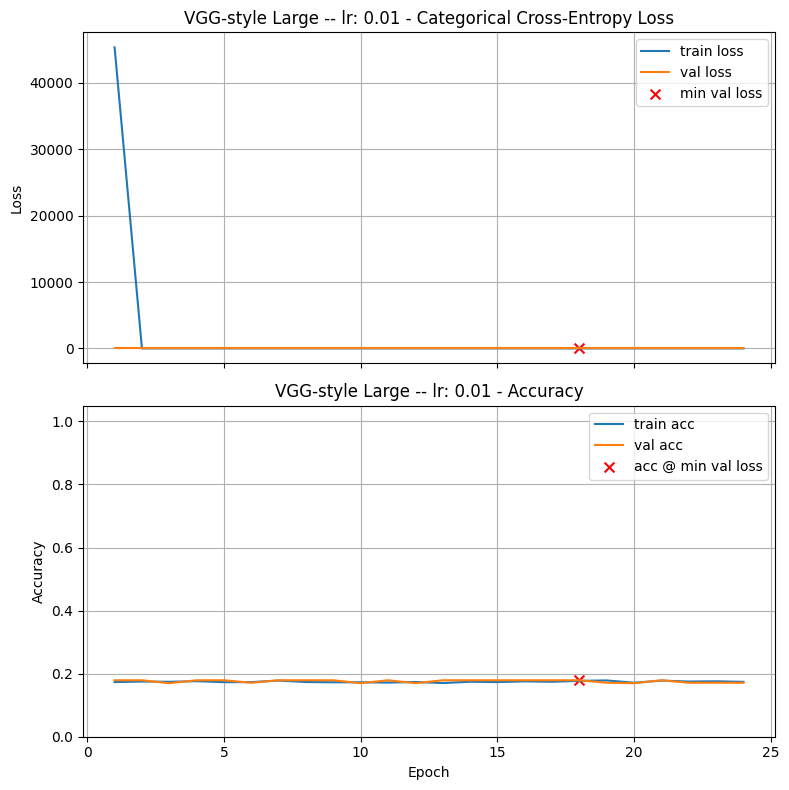

Final Training Loss:            1.8079
Final Training Accuracy:        0.1740
Final Validation Loss:          1.8084
Final Validation Accuracy:      0.1712
Minimum Validation Loss:        1.8072 (Epoch 18)
Validation Accuracy @ Min Loss: 0.1790

Test Loss: 1.8073
Test Accuracy: 0.1750

Validation-Test Gap (accuracy): 0.004030

Execution Time: 00:03:45

Running VGG-16 with LR: 0.003

VGG-style Large -- lr: 0.003



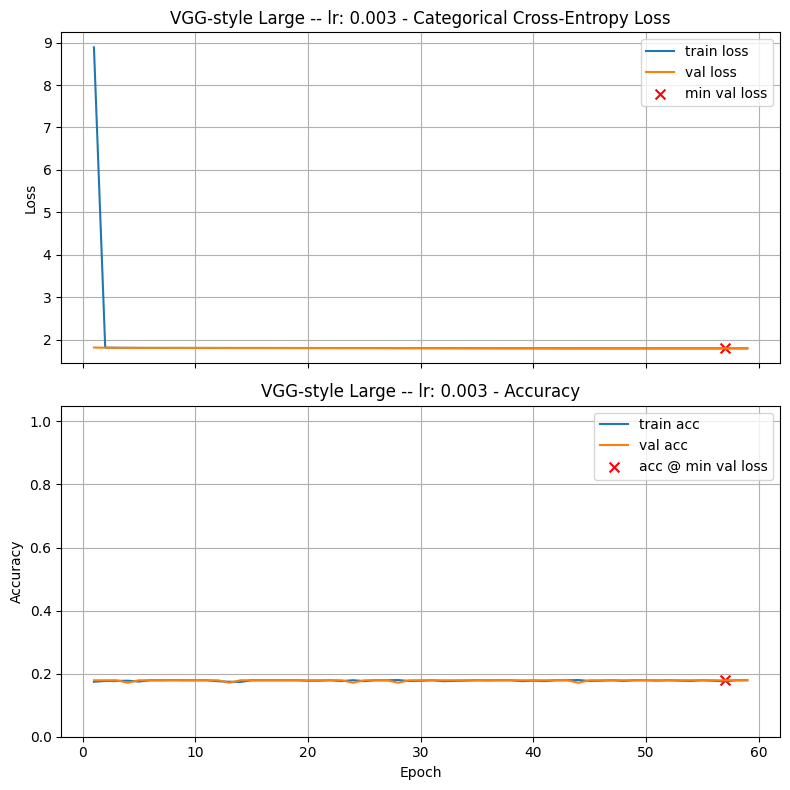

Final Training Loss:            1.7913
Final Training Accuracy:        0.1790
Final Validation Loss:          1.7908
Final Validation Accuracy:      0.1790
Minimum Validation Loss:        1.7908 (Epoch 57)
Validation Accuracy @ Min Loss: 0.1790

Test Loss: 1.7901
Test Accuracy: 0.1750

Validation-Test Gap (accuracy): 0.004030

Execution Time: 00:08:50

Running VGG-16 with LR: 0.001

VGG-style Large -- lr: 0.001



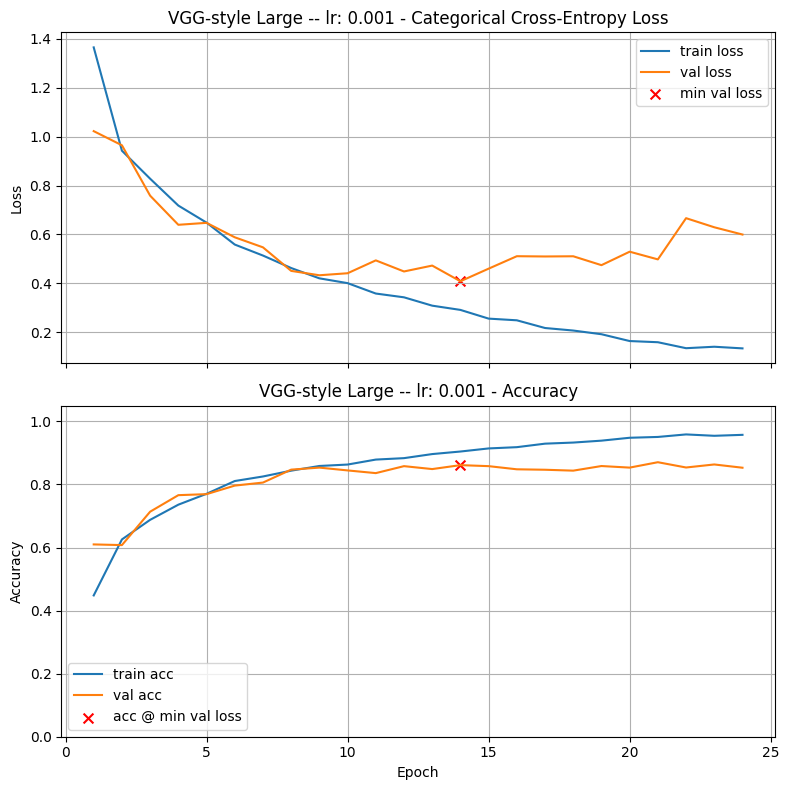

Final Training Loss:            0.1350
Final Training Accuracy:        0.9573
Final Validation Loss:          0.5998
Final Validation Accuracy:      0.8531
Minimum Validation Loss:        0.4090 (Epoch 14)
Validation Accuracy @ Min Loss: 0.8613

Test Loss: 0.4336
Test Accuracy: 0.8593

Validation-Test Gap (accuracy): 0.001936

Execution Time: 00:03:45

Running VGG-16 with LR: 0.0003

VGG-style Large -- lr: 0.0003



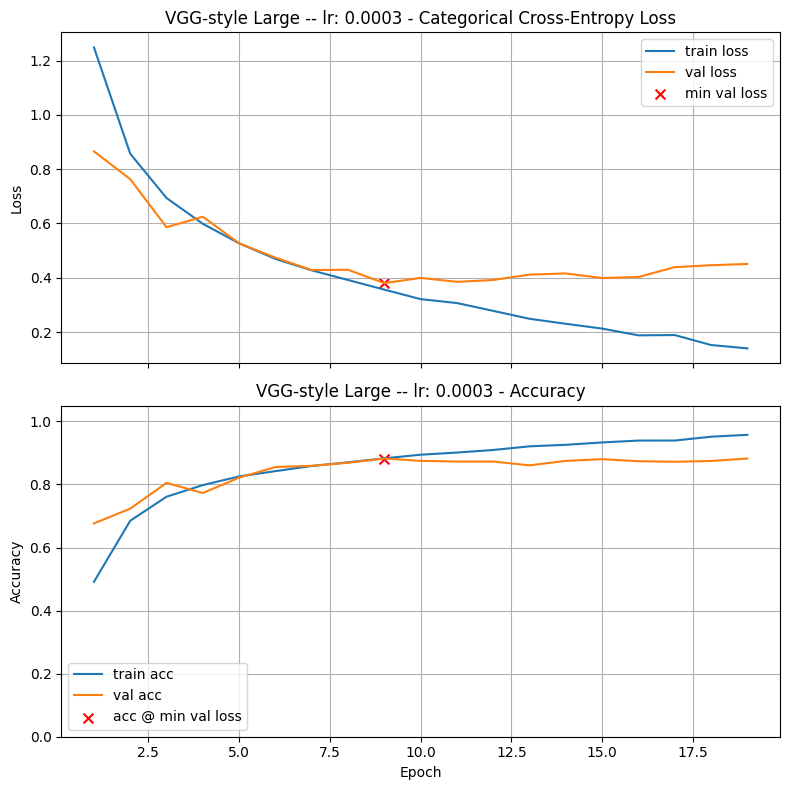

Final Training Loss:            0.1398
Final Training Accuracy:        0.9573
Final Validation Loss:          0.4508
Final Validation Accuracy:      0.8823
Minimum Validation Loss:        0.3802 (Epoch 9)
Validation Accuracy @ Min Loss: 0.8823

Test Loss: 0.3802
Test Accuracy: 0.8763

Validation-Test Gap (accuracy): 0.005978

Execution Time: 00:03:02

Running VGG-16 with LR: 0.0001

VGG-style Large -- lr: 0.0001



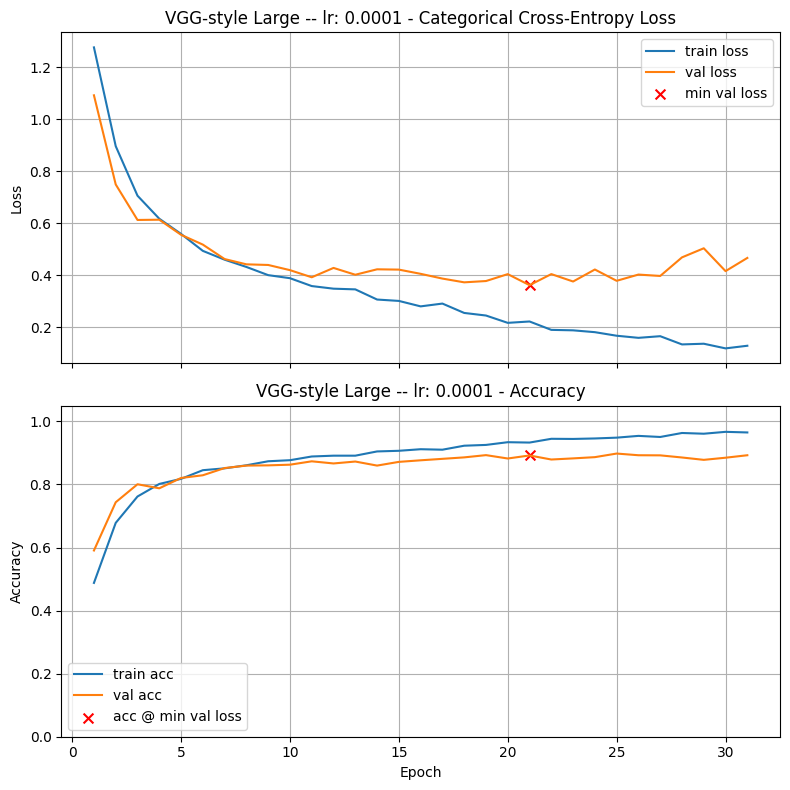

Final Training Loss:            0.1280
Final Training Accuracy:        0.9649
Final Validation Loss:          0.4659
Final Validation Accuracy:      0.8927
Minimum Validation Loss:        0.3612 (Epoch 21)
Validation Accuracy @ Min Loss: 0.8919

Test Loss: 0.3632
Test Accuracy: 0.8923

Validation-Test Gap (accuracy): 0.000393

Execution Time: 00:04:47

Running VGG-16 with LR: 3e-05

VGG-style Large -- lr: 3e-05



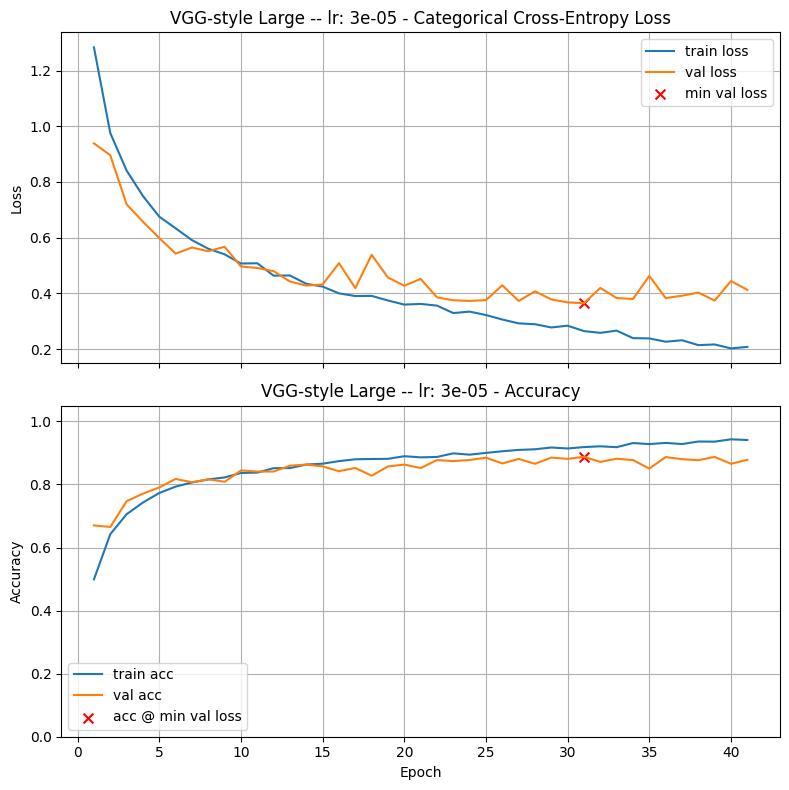

Final Training Loss:            0.2076
Final Training Accuracy:        0.9410
Final Validation Loss:          0.4124
Final Validation Accuracy:      0.8780
Minimum Validation Loss:        0.3645 (Epoch 31)
Validation Accuracy @ Min Loss: 0.8877

Test Loss: 0.3660
Test Accuracy: 0.8913

Validation-Test Gap (accuracy): 0.003673

Execution Time: 00:06:17

Running VGG-16 with LR: 1e-05

VGG-style Large -- lr: 1e-05



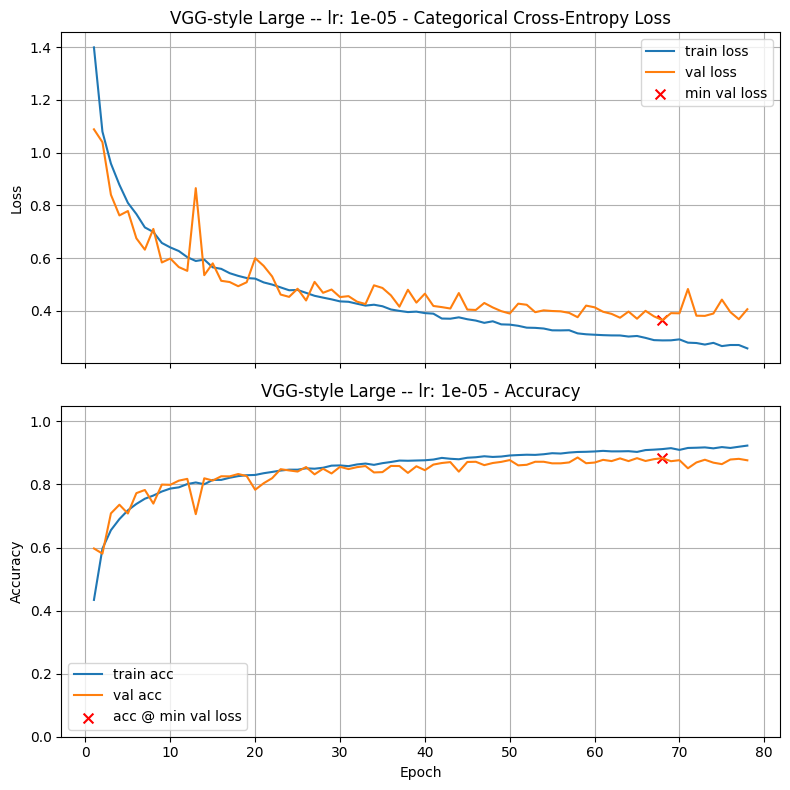

Final Training Loss:            0.2573
Final Training Accuracy:        0.9232
Final Validation Loss:          0.4059
Final Validation Accuracy:      0.8766
Minimum Validation Loss:        0.3646 (Epoch 68)
Validation Accuracy @ Min Loss: 0.8834

Test Loss: 0.3684
Test Accuracy: 0.8937

Validation-Test Gap (accuracy): 0.010286

Execution Time: 00:11:43

Problem 5 experiments completed. Summary:
Problem 4 -- ReduceLROnPlateau (factor=0.2, dropout=0.2)	0.8941	33
VGG-style Large -- lr: 0.0001           	0.8919	21
VGG-style Large -- lr: 3e-05            	0.8877	31
VGG-style Large -- lr: 1e-05            	0.8834	68
VGG-style Large -- lr: 0.0003           	0.8823	9
Problem 3 -- GAP + Tweak 6 -- Dropout 0.2	0.8684	32
Problem 3 -- GAP + Tweak 2 + 6 -- 64->128 + Dropout 0.2	0.8655	22
VGG-style Large                         	0.8648	11
Problem 4 -- ReduceLROnPlateau (factor=0.3, dropout=0.2)	0.8641	21
Problem 4 -- ReduceLROnPlateau (factor=0.5, patience=5, dropout=0.2)	0.8623	28
VGG-style Large --

In [66]:
# Problem 5: Learning Rate Sweep for VGG-16

# List of learning rates to try as suggested in the instructions
lrs_to_test = [1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5]

for lr in lrs_to_test:
    # Re-define model to ensure fresh weights for each run
    he = initializers.HeNormal()
    l2reg = regularizers.l2(1e-4)

    model_vgg_16 = models.Sequential([
        layers.Input(shape=(150, 150, 3)),

        # Block 1
        layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
        layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
        layers.MaxPooling2D(),

        # Block 2
        layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
        layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
        layers.MaxPooling2D(),

        # Block 3
        layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
        layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
        layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
        layers.MaxPooling2D(),

        # Block 4 (NO MaxPool here -> leaves 3x3x512)
        layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
        layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
        layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

        layers.GlobalAveragePooling2D(),

        # Compact head
        layers.Dense(256, activation='relu', kernel_initializer=he, kernel_regularizer=l2reg),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    print(f"\nRunning VGG-16 with LR: {lr}")
    # Use a descriptive title to track results
    train_and_test(model_vgg_16, lr_schedule=lr, title=f"VGG-style Large -- lr: {lr}")

print("\n" + "="*70)
print("Problem 5 experiments completed. Summary:")
print_results()


VGG-style Large



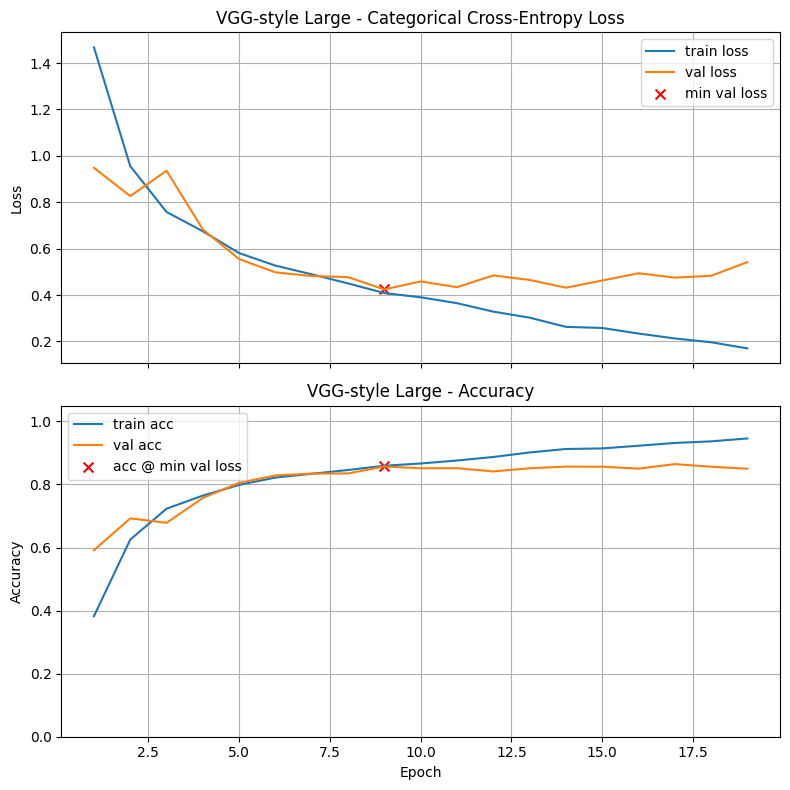

Final Training Loss:            0.1700
Final Training Accuracy:        0.9459
Final Validation Loss:          0.5416
Final Validation Accuracy:      0.8499
Minimum Validation Loss:        0.4242 (Epoch 9)
Validation Accuracy @ Min Loss: 0.8570

Test Loss: 0.4383
Test Accuracy: 0.8517

Validation-Test Gap (accuracy): 0.005323

Execution Time: 00:03:02


In [67]:
he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)   # set to None to disable or tweak the value

model_vgg_16 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 4 (NO MaxPool here -> leaves 3×3×512)
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

    # Global pooling meaningfully summarizes the 3×3 map
    layers.GlobalAveragePooling2D(),   # swap to GlobalMaxPooling2D() to compare

    # Compact head
    layers.Dense(256, activation='relu', kernel_initializer=he,
                 kernel_regularizer=l2reg),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Uncomment the next line to run

train_and_test(model_vgg_16,lr_schedule=1e-3,title="VGG-style Large")



Running VGG-16 with LR: 0.0001

VGG-style Large -- lr: 0.0001 -- Larger Head



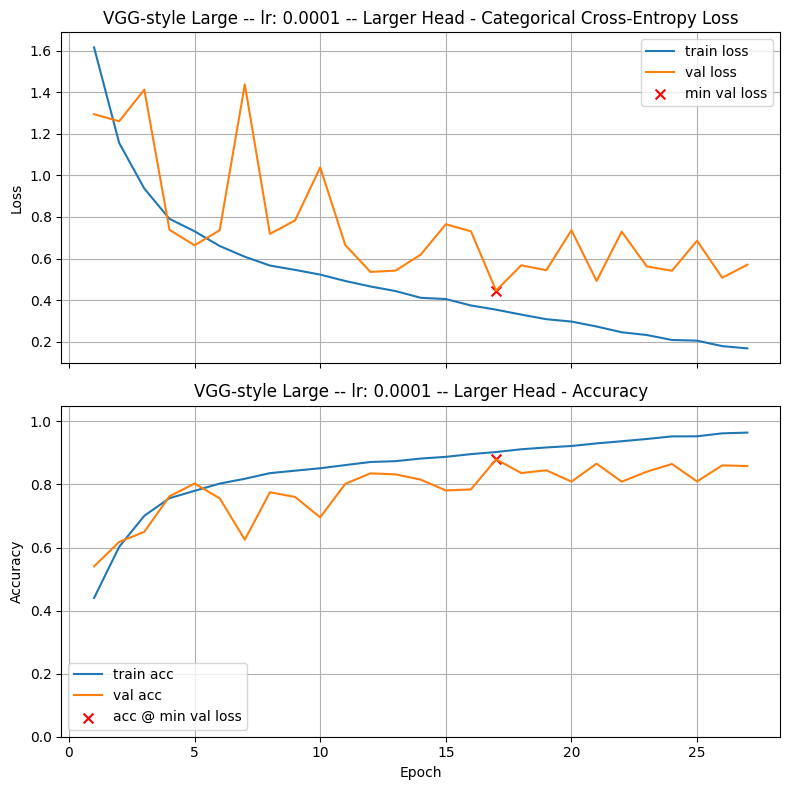

Final Training Loss:            0.1680
Final Training Accuracy:        0.9645
Final Validation Loss:          0.5704
Final Validation Accuracy:      0.8584
Minimum Validation Loss:        0.4461 (Epoch 17)
Validation Accuracy @ Min Loss: 0.8798

Test Loss: 0.4349
Test Accuracy: 0.8807

Validation-Test Gap (accuracy): 0.000852

Execution Time: 00:04:52

Problem 5 experiments completed. Summary:
VGG-style Large -- lr: 0.0001 -- Larger Head	0.8798	17


In [8]:
# Problem 5: Learning Rate 0.0001 for VGG-16 -- Large Head

# Re-define model to ensure fresh weights for each run
he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)

model_vgg_16 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 4 (NO MaxPool here -> leaves 3x3x512)
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

    layers.GlobalAveragePooling2D(),

    layers.Dense(512, activation='relu', kernel_initializer=he, kernel_regularizer=l2reg),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu', kernel_initializer=he, kernel_regularizer=l2reg),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
])

print(f"\nRunning VGG-16 with LR: 0.0001")
# Use a descriptive title to track results
train_and_test(model_vgg_16, lr_schedule=0.0001, title=f"VGG-style Large -- lr: 0.0001 -- Larger Head")

print("\n" + "="*70)
print("Problem 5 experiments completed. Summary:")
print_results()

### Graded Questions

In [9]:
# Set a5a to the learning rate which gave the best validation accuracy at the point of minimum validation loss

a5a = 0.0001             # Replace with your best learning rate

In [10]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a5a = {a5a:.8f}')

a5a = 0.00010000


In [11]:
# Set a5b to the validation accuracy found by the choice specified in Question a5a (your best model for this problem)

a5b = 0.8919              # Replace 0.0 with your answer

In [12]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a5b = {a5b:.4f}')

a5b = 0.8919


## All Results

This will print out the results from all experiments, with titles as keys. I use this all the time to keep track of experiments!

In [68]:
print_results()

Problem 4 -- ReduceLROnPlateau (factor=0.2, dropout=0.2)	0.8941	33
VGG-style Large -- lr: 0.0001           	0.8919	21
VGG-style Large -- lr: 3e-05            	0.8877	31
VGG-style Large -- lr: 1e-05            	0.8834	68
VGG-style Large -- lr: 0.0003           	0.8823	9
Problem 3 -- GAP + Tweak 6 -- Dropout 0.2	0.8684	32
Problem 3 -- GAP + Tweak 2 + 6 -- 64->128 + Dropout 0.2	0.8655	22
Problem 4 -- ReduceLROnPlateau (factor=0.3, dropout=0.2)	0.8641	21
Problem 4 -- ReduceLROnPlateau (factor=0.5, patience=5, dropout=0.2)	0.8623	28
VGG-style Large -- lr: 0.001            	0.8613	14
Problem 4 -- ReduceLROnPlateau (factor=0.5, dropout=0.2)	0.8588	29
Problem 3 -- GAP + Tweak 1 -- lr: 5e-4  	0.8577	26
VGG-style Large                         	0.8570	9
Problem 3 -- GAP + Tweaks 2 & 1         	0.8566	18
Problem 4 -- ReduceLROnPlateau (factor=0.5, min_delta=1e-3, dropout=0.2)	0.8556	34
Problem 3 -- GAP + Tweak 2 -- Conv: 64->128	0.8520	12
Problem 3 -- BatchNorm + GAP -- Baseline	0.8270	13
Baseline

    VGG-style Large -- lr: 0.0001           	0.8700	18
    Model with ReduceLROnPlateau            	0.8636	227
    VGG-style Large -- lr: 0.0003           	0.8400	23
    VGG-style Large -- lr: 1e-05            	0.8301	60
    VGG-style Large -- lr: 3e-05            	0.8269	26
    Baseline model using BatchNormalization -- Tweak 2 -- 64 -> 128	0.8140	33
    Baseline Plus -- Tweaks 5 & 6 -- Do: 0.3	0.8030	50
    Baseline model using BatchNormalization -- Tweak 3 -- 32 -> 64 -> 128	0.8019	26
    Baseline model using BatchNormalization -- Tweak 4 -- Dense 128	0.7976	24
    Baseline model using BatchNormalization 	0.7941	7
    Baseline Plus -- Tweak 3 -- 32 -> 64 -> 128	0.7912	20
    Baseline Plus -- Tweak 6 -- Do: 0.3     	0.7745	36
    Baseline Plus -- Tweak 2 -- 64 -> 128   	0.7645	25
    Baseline Plus -- Tweak 5 -- L2: 1e-4    	0.7570	27
    Model using GAP                         	0.7553	10
    Baseline Plus -- Two Tweaks! -- L2: 1e-4 Do: 0.3	0.7506	19
    VGG-style Large -- lr: 0.001            	0.6865	5
    Baseline Plus -- Tweak 4 -- Dense 128   	0.5999	1
    Baseline Plus -- Tweak 1 -- lr: 1e-4    	0.4817	3
    Baseline model using BatchNormalization -- Tweak 1 lr: 0.0001 	0.3691	1
    VGG-style Large -- lr: 0.01             	0.1792	95
    VGG-style Large -- lr: 0.003            	0.1792	195
    Baseline Model                          	0.0000	1